In [1]:
import matplotlib.pyplot as plt
import matplotlib
import numpy as np
import pickle
import yaml
import pandas as pd
import os
import getdist
from getdist import plots, MCSamples
import sacc
import pacc
import random
plt.rcParams['xtick.labelsize'] = 22
plt.rcParams['ytick.labelsize'] = 18
plt.rcParams['axes.labelsize'] = 18
plt.rcParams['axes.titlesize'] = 22
plt.rcParams.update({'font.size': 22})
plt.rc('legend',fontsize=18)
print('matplotlib: {}'.format(matplotlib.__version__))

matplotlib: 3.10.0


In [2]:
xi2_bias = np.load("./sompz_fake_chains/CosmoDC2_Xi2_sompz.npz", allow_pickle=True)
xi2_bias_dummy = MCSamples(samples=xi2_bias["Xi2_dummy"]/437, names=["Xi2"], labels=["\chi^2 / dof"], label=r"$\Delta_z$",
                        settings={'mult_bias_correction_order':0,'smooth_scale_2D':0.4, 'smooth_scale_1D':0.3})
xi2_bias_dz = MCSamples(samples=xi2_bias["Xi2_dz"]/437, names=["Xi2"], labels=["\chi^2 / dof"], label=r"$\Delta_z$",
                    settings={'mult_bias_correction_order':0,'smooth_scale_2D':0.4, 'smooth_scale_1D':0.3})
xi2_bias_wzdz = MCSamples(samples=xi2_bias["Xi2_wzdz"]/437, names=["Xi2"], labels=["\chi^2 / dof"], label=r"$\Delta_z$",
                    settings={'mult_bias_correction_order':0,'smooth_scale_2D':0.4, 'smooth_scale_1D':0.3})
xi2_bias_gp = MCSamples(samples=xi2_bias["Xi2_gp"]/437, names=["Xi2"], labels=["\chi^2 / dof"], label=r"$\Delta_z$",
                        settings={'mult_bias_correction_order':0,'smooth_scale_2D':0.4, 'smooth_scale_1D':0.3})
xi2_bias_pca = MCSamples(samples=xi2_bias["Xi2_PCA"]/437, names=["Xi2"], labels=["\chi^2 / dof"], label=r"$\Delta_z$",
                        settings={'mult_bias_correction_order':0,'smooth_scale_2D':0.4, 'smooth_scale_1D':0.3})

Removed no burn in
Removed no burn in
Removed no burn in
Removed no burn in
Removed no burn in


<>:2: SyntaxWarning: invalid escape sequence '\c'
<>:4: SyntaxWarning: invalid escape sequence '\c'
<>:6: SyntaxWarning: invalid escape sequence '\c'
<>:8: SyntaxWarning: invalid escape sequence '\c'
<>:10: SyntaxWarning: invalid escape sequence '\c'
<>:2: SyntaxWarning: invalid escape sequence '\c'
<>:4: SyntaxWarning: invalid escape sequence '\c'
<>:6: SyntaxWarning: invalid escape sequence '\c'
<>:8: SyntaxWarning: invalid escape sequence '\c'
<>:10: SyntaxWarning: invalid escape sequence '\c'
/tmp/ipykernel_18760/4275441909.py:2: SyntaxWarning: invalid escape sequence '\c'
  xi2_bias_dummy = MCSamples(samples=xi2_bias["Xi2_dummy"]/437, names=["Xi2"], labels=["\chi^2 / dof"], label=r"$\Delta_z$",
/tmp/ipykernel_18760/4275441909.py:4: SyntaxWarning: invalid escape sequence '\c'
  xi2_bias_dz = MCSamples(samples=xi2_bias["Xi2_dz"]/437, names=["Xi2"], labels=["\chi^2 / dof"], label=r"$\Delta_z$",
/tmp/ipykernel_18760/4275441909.py:6: SyntaxWarning: invalid escape sequence '\c'
  xi2_bi

In [3]:
print(np.median(xi2_bias["Xi2_dummy"])/437)
print(np.median(xi2_bias["Xi2_dz"])/437)
print(np.median(xi2_bias["Xi2_wzdz"])/437)
print(np.median(xi2_bias["Xi2_gp"])/437)
print(np.median(xi2_bias["Xi2_PCA"])/437)

0.16410399728970004
0.030946109505560156
0.025450368691933362
0.01908750607200348
0.005634793813434609


/tmp/ipykernel_18760/3502310488.py:15: UserWarning: set_ticklabels() should only be used with a fixed number of ticks, i.e. after set_ticks() or using a FixedLocator.
  g.fig.axes[0].set_xticklabels([0, 0.05, 0.1, 0.15, 0.2], fontsize=16)


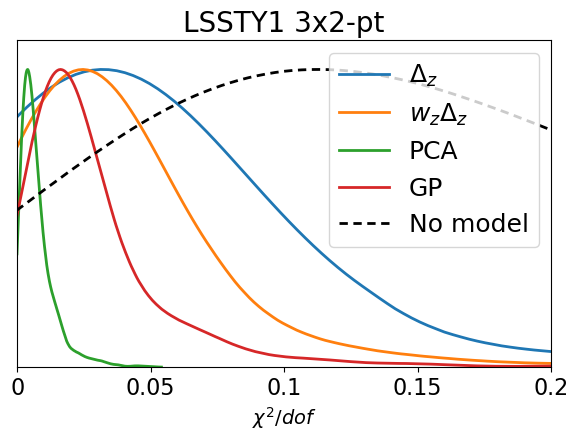

In [4]:
g = plots.get_single_plotter()

ax = g.plot_1d([
    xi2_bias_dz,
    xi2_bias_wzdz,
    xi2_bias_pca,
    xi2_bias_gp,
    xi2_bias_dummy,
    ], 'Xi2', 
    colors=['C0', 'C1', 'C2', 'C3', "black"],
    ls=['-', '-', '-', '-', '--'], 
    lws=2,
    param_limits={'Xi2':(0, 100)})
g.fig.axes[0].set_xlim(0.0, 0.2)
g.fig.axes[0].set_xticklabels([0, 0.05, 0.1, 0.15, 0.2], fontsize=16)
#g.fig.axes[0].set_xscale('symlog', linthresh=100)
g.add_legend([r'$\Delta_z$', r'$w_z \Delta_z$', 'PCA', 'GP', 'No model'],
             legend_loc='upper right', fontsize=18)
g.fig.axes[0].set_title("LSSTY1 3x2-pt", fontsize=20)
g.export("./paper_plots/Y1_bias_comparison.pdf")


In [5]:
prat_markers = {'h': 0.7189925511925751,
               'Ωm': 0.2734714358876248,
               'Ωb': 0.042170616570847225,
               'ns': 0.9965136823002241,
               'σ8': 0.7790071910238021,
               'lens_0_b':0.879118,
               'lens_1_b':1.05894, 
               'lens_2_b':1.22145, 
               'lens_3_b':1.35065, 
               'lens_4_b':1.58909,
               'A_IA':0.25179439}

## Load Data

In [6]:
s_3x2 = sacc.Sacc.load_fits("/home/jaimerzp/Documents/UCL/3x2_analytical/data/CosmoDC2/summary_statistics_fourier_tjpcov.sacc")
y_3x2 = yaml.load(open("/home/jaimerzp/Documents/UCL/3x2_analytical/data/CosmoDC2/gcgc_gcwl_wlwl.yml"), Loader=yaml.FullLoader)

Assuming data rows are in the correct order as it was before version 1.0.


In [7]:
cle_3x2  = pacc.ClsEnsemble(s_3x2, y_3x2,   label="CosmoDC2 3x2  - data")

In [8]:
data = np.load("/home/jaimerzp/Documents/UCL/3x2_analytical/bpz_fake_chains/nomarg/CosmoDC2_3x2_nomarg_TAP_0.65_init_ϵ_0.03/data_1.npz")
cle_3x2_fake = pacc.ClTheoryEnsemble(cle_3x2, data["data"], label="CosmoDC2 3x2 - Synthetic data")

In [9]:
tpts = np.load("covs/COSMODC2/bpz_3x2_tpts_covs.npz")
cov = np.diag(tpts["cov"])
tt_dz   = np.diag(tpts["TT_dz"])   - cov
tt_wzdz = np.diag(tpts["TT_wzdz"]) - cov
tt_pca  = np.diag(tpts["TT_pca"])  - cov
tt_gp   = np.diag(tpts["TT_gp"])   - cov
total_l = 0
_tt_dz = []
_tt_wzdz = []
_tt_pca = []
_tt_gp = []
_cov = []
for d in cle_3x2.data:
    dz = tt_dz[total_l:total_l+len(d)]
    wzdz = tt_wzdz[total_l:total_l+len(d)]
    pca = tt_pca[total_l:total_l+len(d)]
    gp = tt_gp[total_l:total_l+len(d)]
    c = cov[total_l:total_l+len(d)]
    _tt_dz.append(dz/c)
    _tt_wzdz.append(wzdz/c)
    _tt_pca.append(pca/c)
    _tt_gp.append(gp/c)
    _cov.append(c)
    total_l += len(d)

cle_3x2_tt_dz = pacc.ClsEnsemble(s_3x2, y_3x2,   label=r"$\delta z$")
cle_3x2_tt_dz.errs = _tt_dz
cle_3x2_tt_wzdz = pacc.ClsEnsemble(s_3x2, y_3x2,   label=r"$w_z \, \delta z$")
cle_3x2_tt_wzdz.errs = _tt_wzdz
cle_3x2_tt_pca = pacc.ClsEnsemble(s_3x2, y_3x2,   label="PCA")
cle_3x2_tt_pca.errs = _tt_pca
cle_3x2_tt_gp = pacc.ClsEnsemble(s_3x2, y_3x2,   label="GP")
cle_3x2_tt_gp.errs = _tt_gp

In [10]:
labels = [
    r'$\left(\frac{\partial t^{\rm lens \, 1} \partial t^{\rm lens \, 1}}{\partial_\theta^2}\right)/ \mathbb{C}$',
    r'$\left(\frac{\partial t^{\rm lens \, 2} \partial t^{\rm lens \, 2}}{\partial_\theta^2}\right)/ \mathbb{C}$',
    r'$\left(\frac{\partial t^{\rm lens \, 3} \partial t^{\rm lens \, 3}}{\partial_\theta^2}\right)/ \mathbb{C}$',
    r'$\left(\frac{\partial t^{\rm lens \, 4} \partial t^{\rm lens \, 4}}{\partial_\theta^2}\right)/ \mathbb{C}$',
    r'$\left(\frac{\partial t^{\rm lens \, 5} \partial t^{\rm lens \, 5}}{\partial_\theta^2}\right)/ \mathbb{C}$',
    r'$\left(\frac{\partial t^{\rm source \, 1} \partial t^{\rm source \, 1}}{\partial_\theta^2}\right)/ \mathbb{C}$',
    r'$\left(\frac{\partial t^{\rm source \, 2} \partial t^{\rm source \, 2}}{\partial_\theta^2}\right)/ \mathbb{C}$',
    r'$\left(\frac{\partial t^{\rm source \, 3} \partial t^{\rm source \, 3}}{\partial_\theta^2}\right)/ \mathbb{C}$',
    r'$\left(\frac{\partial t^{\rm source \, 4} \partial t^{\rm source \, 4}}{\partial_\theta^2}\right)/ \mathbb{C}$',
    r'$\left(\frac{\partial t^{\rm source \, 5} \partial t^{\rm source \, 5}}{\partial_\theta^2}\right)/ \mathbb{C}$',
]

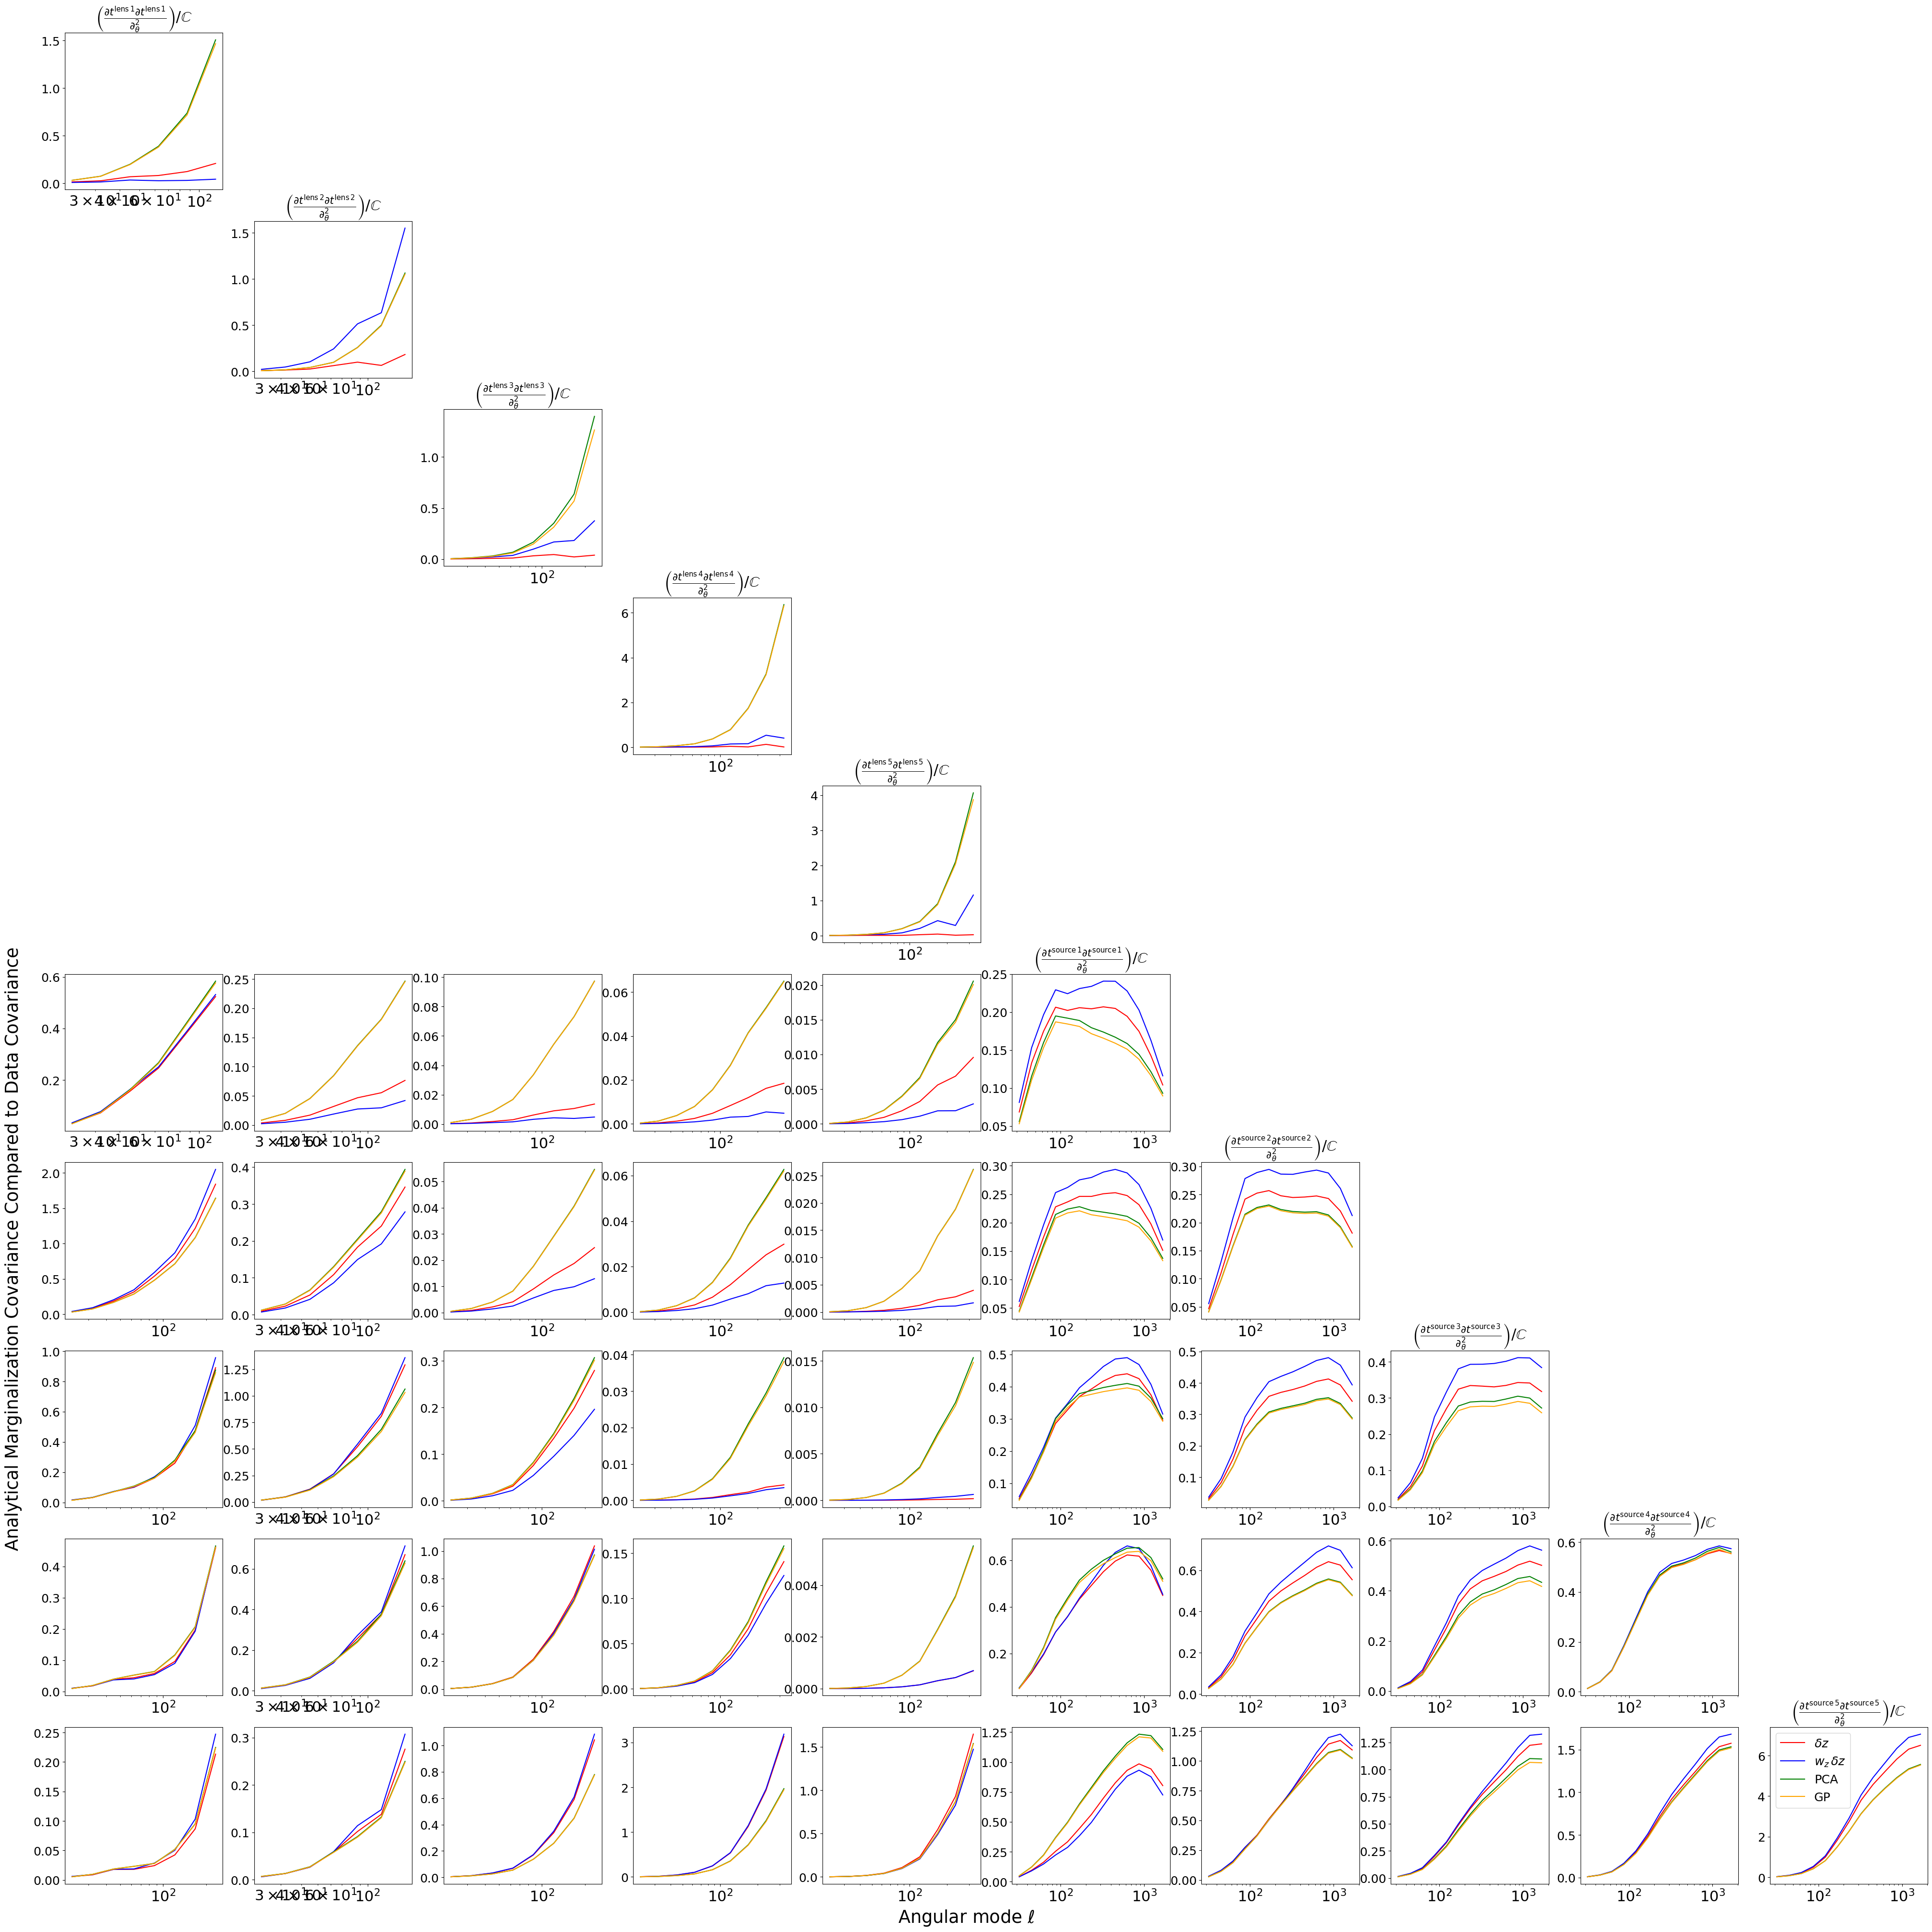

In [11]:
colors = ['r', 'b', 'g', 'orange']
g = pacc.plot_errs([[cle_3x2_tt_dz, cle_3x2_tt_wzdz, cle_3x2_tt_pca, cle_3x2_tt_gp]], cle_3x2.pairs,
               configs=[{'colors': colors},
                        {'colors': colors}, 
                        {'colors': colors}, 
                        {'colors': colors}],
                labels=labels);
g.savefig("./paper_plots/tpts_3x2.pdf", bbox_inches='tight')

In [12]:
labels = [
    r'$C_\ell^{\rm lens 1 \, lens 1}$',
    r'$C_\ell^{\rm lens 2 \, lens 2}$',
    r'$C_\ell^{\rm lens 3 \, lens 3}$',
    r'$C_\ell^{\rm lens 4 \, lens 4}$',
    r'$C_\ell^{\rm lens 5 \, lens 5}$',
    r'$C_\ell^{\rm source 1 \, source 1}$',
    r'$C_\ell^{\rm source 2 \, source 2}$',
    r'$C_\ell^{\rm source 3 \, source 3}$',
    r'$C_\ell^{\rm source 4 \, source 4}$',
    r'$C_\ell^{\rm source 5 \, source 5}$',
]

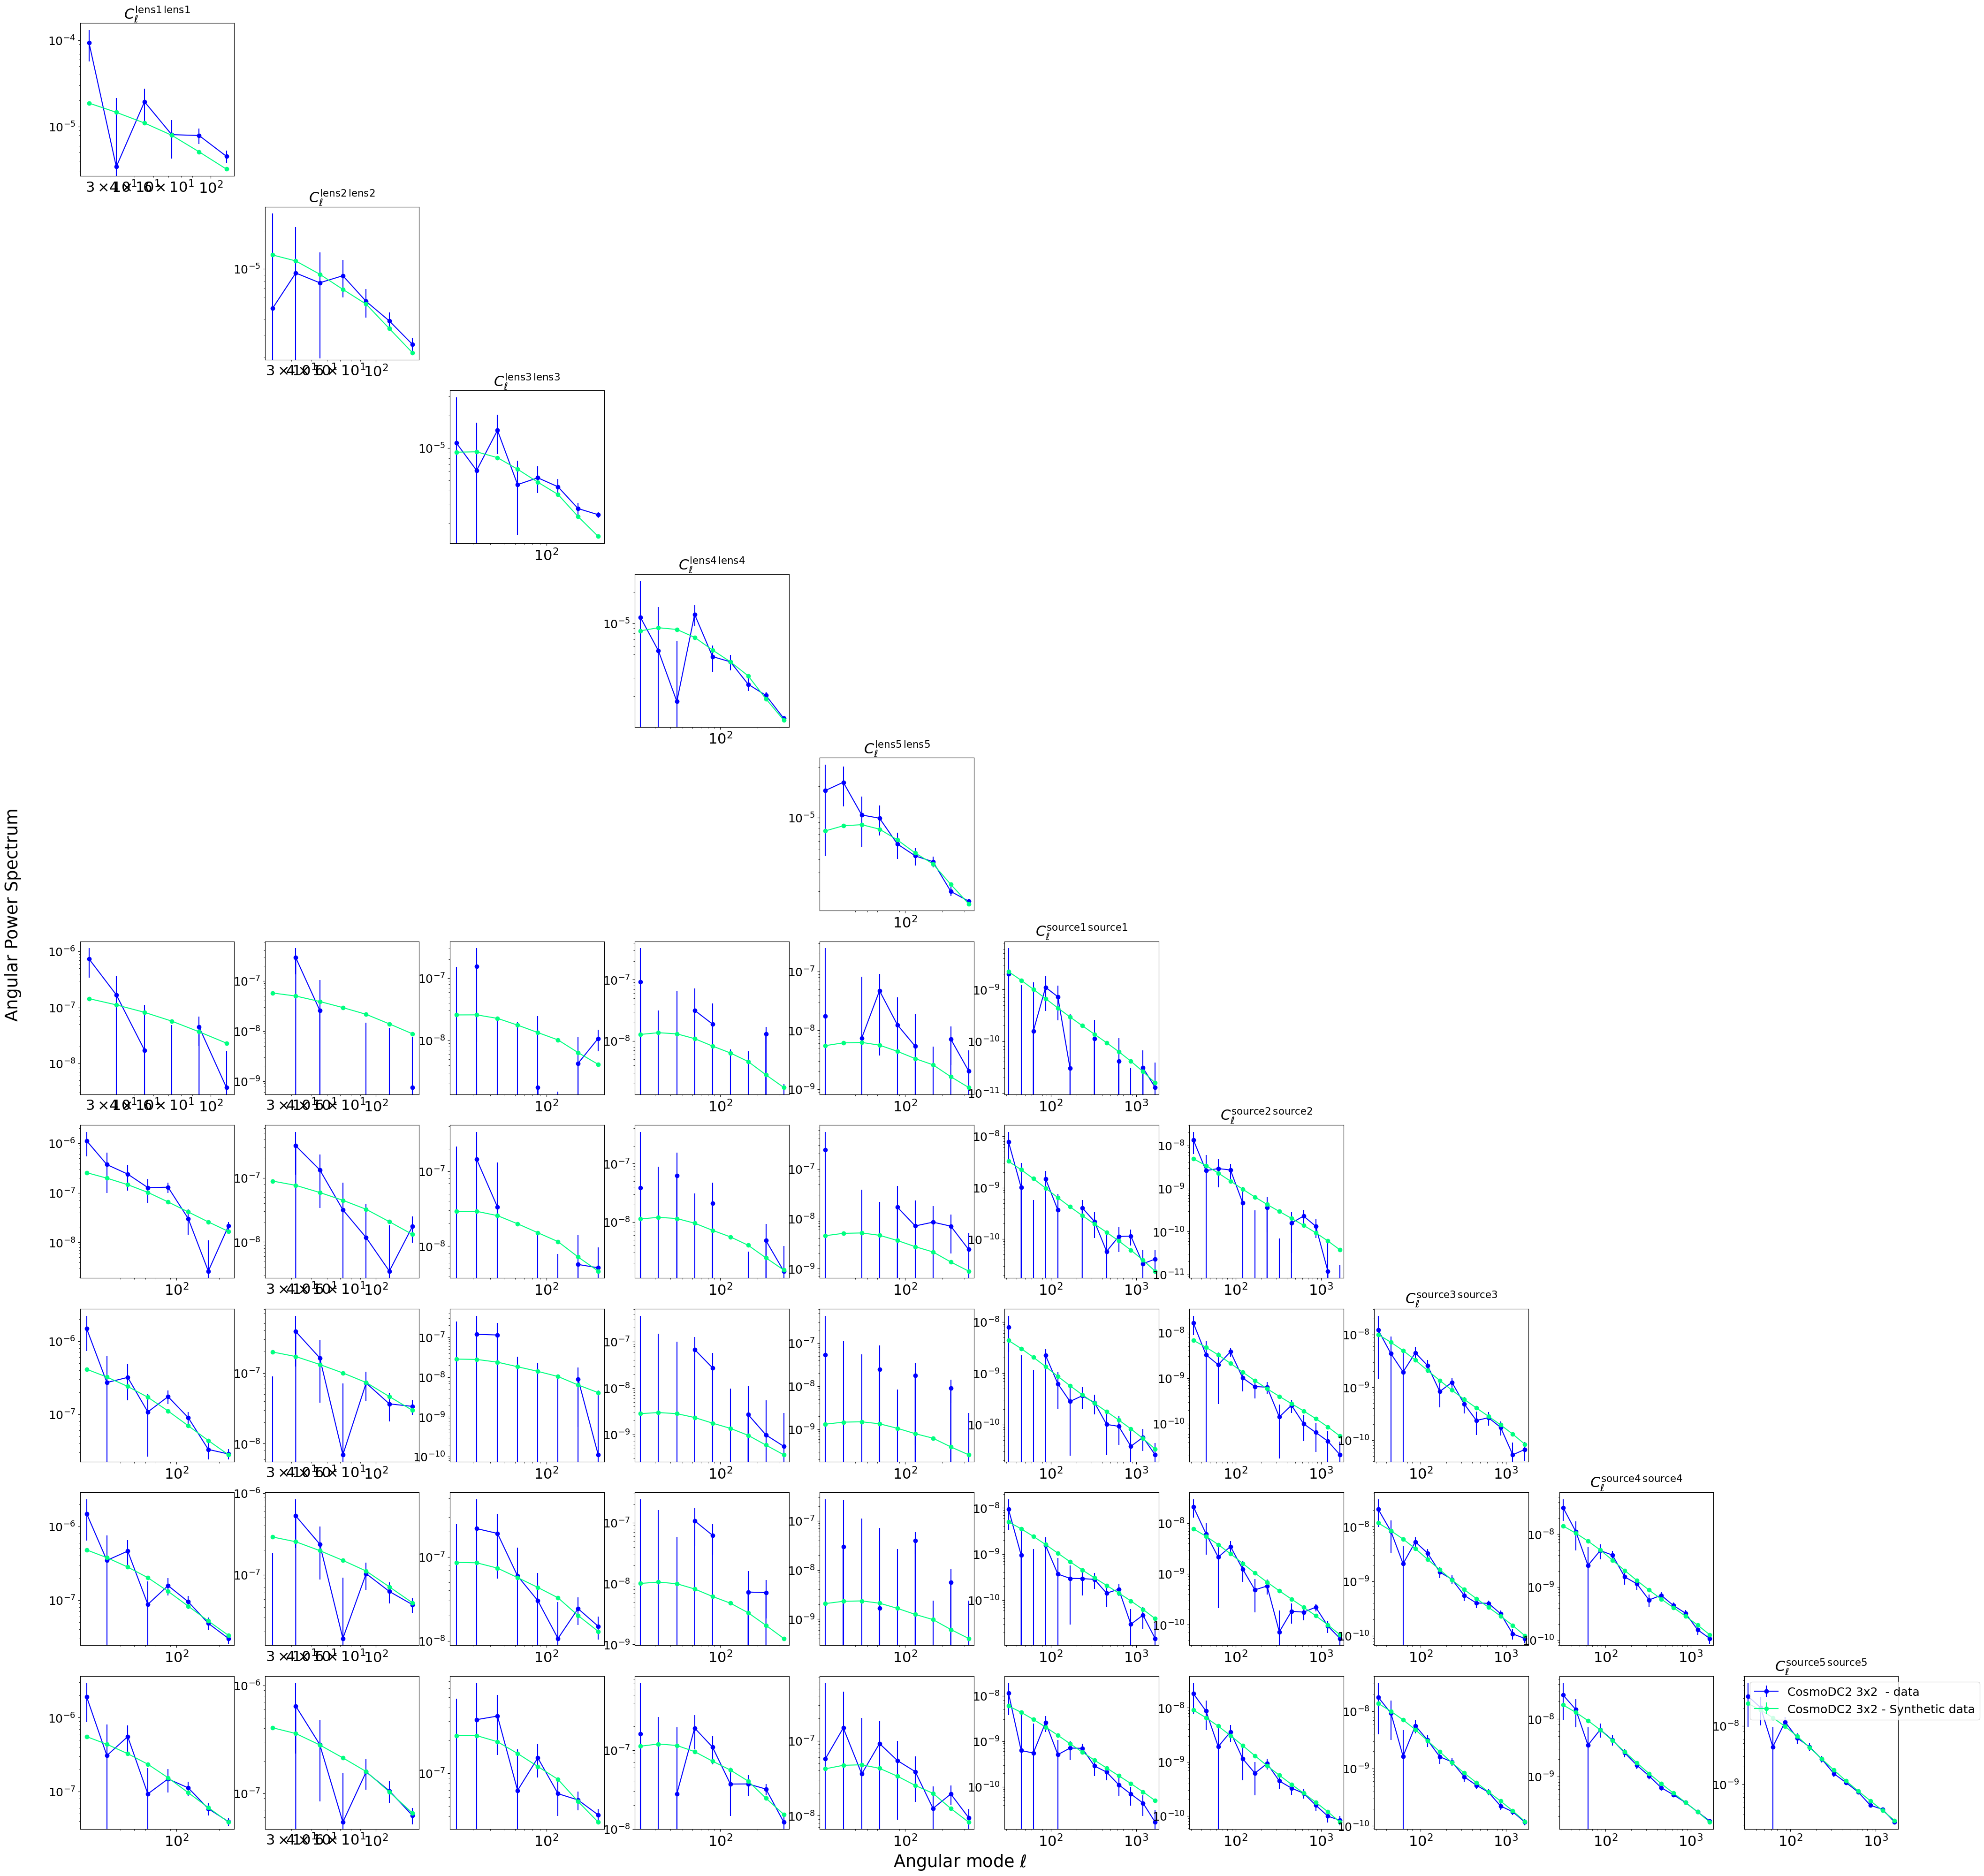

In [13]:
g = pacc.plot_cls([[cle_3x2, cle_3x2_fake]], cle_3x2.pairs, labels=labels);
g.savefig("./paper_plots/data_3x2.pdf", bbox_inches='tight')

In [14]:
from numpy.random import multivariate_normal as mvn
wzdz_path = "./data/CosmoDC2/nzs_sompz/wzdz_priors/"
nz_lens_0 = np.load(wzdz_path + "wzdz_lens_0.npz")
nz_lens_1 = np.load(wzdz_path + "wzdz_lens_1.npz")
nz_lens_2 = np.load(wzdz_path + "wzdz_lens_2.npz")
nz_lens_3 = np.load(wzdz_path + "wzdz_lens_3.npz")
nz_lens_4 = np.load(wzdz_path + "wzdz_lens_4.npz")
nz_source_0 = np.load(wzdz_path + "wzdz_source_0.npz")
nz_source_1 = np.load(wzdz_path + "wzdz_source_1.npz")
nz_source_2 = np.load(wzdz_path + "wzdz_source_2.npz")
nz_source_3 = np.load(wzdz_path + "wzdz_source_3.npz")
nz_source_4 = np.load(wzdz_path + "wzdz_source_4.npz")

thetas_lens_0 = np.array([np.array([0, 1]) + mvn(np.zeros(2), nz_lens_0["cov"]) for _ in range(10000)]).T
thetas_lens_1 = np.array([np.array([0, 1]) + mvn(np.zeros(2), nz_lens_1["cov"]) for _ in range(10000)]).T
thetas_lens_2 = np.array([np.array([0, 1]) + mvn(np.zeros(2), nz_lens_2["cov"]) for _ in range(10000)]).T
thetas_lens_3 = np.array([np.array([0, 1]) + mvn(np.zeros(2), nz_lens_3["cov"]) for _ in range(10000)]).T
thetas_lens_4 = np.array([np.array([0, 1]) + mvn(np.zeros(2), nz_lens_4["cov"]) for _ in range(10000)]).T
thetas_source_0 = np.array([np.array([0, 1]) + mvn(np.zeros(2), nz_source_0["cov"]) for _ in range(10000)]).T
thetas_source_1 = np.array([np.array([0, 1]) + mvn(np.zeros(2), nz_source_1["cov"]) for _ in range(10000)]).T
thetas_source_2 = np.array([np.array([0, 1]) + mvn(np.zeros(2), nz_source_2["cov"]) for _ in range(10000)]).T
thetas_source_3 = np.array([np.array([0, 1]) + mvn(np.zeros(2), nz_source_3["cov"]) for _ in range(10000)]).T
thetas_source_4 = np.array([np.array([0, 1]) + mvn(np.zeros(2), nz_source_4["cov"]) for _ in range(10000)]).T

prior_wzdz_chain = {}
prior_wzdz_chain["dz_lens_0"] = thetas_lens_0[0]
prior_wzdz_chain["wz_lens_0"] = thetas_lens_0[1]
prior_wzdz_chain["dz_lens_1"] = thetas_lens_1[0]
prior_wzdz_chain["wz_lens_1"] = thetas_lens_1[1]
prior_wzdz_chain["dz_lens_2"] = thetas_lens_2[0]
prior_wzdz_chain["wz_lens_2"] = thetas_lens_2[1]
prior_wzdz_chain["dz_lens_3"] = thetas_lens_3[0]
prior_wzdz_chain["wz_lens_3"] = thetas_lens_3[1]
prior_wzdz_chain["dz_lens_4"] = thetas_lens_4[0]
prior_wzdz_chain["wz_lens_4"] = thetas_lens_4[1]
prior_wzdz_chain["dz_source_0"] = thetas_source_0[0]
prior_wzdz_chain["wz_source_0"] = thetas_source_0[1]
prior_wzdz_chain["dz_source_1"] = thetas_source_1[0]
prior_wzdz_chain["wz_source_1"] = thetas_source_1[1]
prior_wzdz_chain["dz_source_2"] = thetas_source_2[0]
prior_wzdz_chain["wz_source_2"] = thetas_source_2[1]
prior_wzdz_chain["dz_source_3"] = thetas_source_3[0]
prior_wzdz_chain["wz_source_3"] = thetas_source_3[1]
prior_wzdz_chain["dz_source_4"] = thetas_source_4[0]
prior_wzdz_chain["wz_source_4"] = thetas_source_4[1]

## Load Chains

In [15]:
def add_chains(paths, start=1, stop=100):
    chains = []
    for path in paths:
        i = start
        while (os.path.isfile(path+"chain_{}.csv".format(i))) & (i<=stop):
            chain = pd.read_csv(path+"chain_{}.csv".format(i))
            chain = pd.DataFrame(np.array(chain)[150:, :], columns=chain.columns)
            chains.append(chain)
            i += 1
    chain = pd.concat(chains)
    return chain

In [16]:
def add_summaries(paths, start=1, stop=100):
    ess_per_secs = []
    mcses = []
    for path in paths:
        i = start
        while (os.path.isfile(path+"summary_{}.csv".format(i))) & (i<=stop):
            ess_per_sec = pd.read_csv(path+"summary_{}.csv".format(i))["ess_per_sec"]
            mcse = pd.read_csv(path+"summary_{}.csv".format(i))["mcse"]
            std = pd.read_csv(path+"summary_{}.csv".format(i))["std"]
            ess_per_secs.append(np.array(ess_per_sec[2:8]))
            mcses.append(np.array(mcse[2:8])/np.array(std[2:8]))
            i += 1
    return [np.mean(ess_per_secs), np.mean(mcse)]

In [17]:
method = "sompz"

path_Y1_3x2_nomarg = f"{method}_fake_chains/nomarg/Y1_3x2_nomarg_TAP_0.65_init_ϵ_0.005/"

path_Y1_3x2_dz_ana = f"{method}_fake_chains/analytical/Y1_3x2_dz_ana_TAP_0.65_init_ϵ_0.005/"
path_Y1_3x2_wzdz_ana = f"{method}_fake_chains/analytical/Y1_3x2_fixed_wzdz_ana_TAP_0.65_init_ϵ_0.005/"
path_Y1_3x2_PCA_ana = f"{method}_fake_chains/analytical/Y1_3x2_PCA_ana_TAP_0.65_init_ϵ_0.005/"
path_Y1_3x2_gp_ana = f"{method}_fake_chains/analytical/Y1_3x2_gp_ana_TAP_0.65_init_ϵ_0.005/"

path_Y1_3x2_dz_num = f"{method}_fake_chains/numerical/Y1_3x2_Gibbs_dz_num_TAP_0.65_init_ϵ1_0.0017320508075688774_init_ϵ2_0.008660254037844387/"
path_Y1_3x2_wzdz_num = f"{method}_fake_chains/numerical/Y1_3x2_Gibbs_fixed_wzdz_num_TAP_0.65_init_ϵ1_0.0017320508075688774_init_ϵ2_0.005196152422706632/"
path_Y1_3x2_PCA_num = f"{method}_fake_chains/numerical/Y1_3x2_Gibbs_PCA_num_TAP_0.65_init_ϵ1_0.0017320508075688774_init_ϵ2_0.008660254037844387/"
path_Y1_3x2_gp_num = f"{method}_fake_chains/numerical/Y1_3x2_Gibbs_gp_num_TAP_0.65_init_ϵ1_0.0017320508075688774_init_ϵ2_0.008660254037844387/"

## Nzs

In [18]:
#chain_Y1_gcgc_nomarg = add_chains([path_Y1_gcgc_nomarg])
#chain_Y1_wlwl_nomarg = add_chains([path_Y1_wlwl_normag])
chain_Y1_3x2_nomarg = add_chains([path_Y1_3x2_nomarg])

chain_Y1_3x2_dz_ana = add_chains([path_Y1_3x2_dz_ana])
chain_Y1_3x2_wzdz_ana = add_chains([path_Y1_3x2_wzdz_ana])
chain_Y1_3x2_PCA_ana = add_chains([path_Y1_3x2_PCA_ana])
chain_Y1_3x2_gp_ana = add_chains([path_Y1_3x2_gp_ana])

chain_Y1_3x2_dz_num = add_chains([path_Y1_3x2_dz_num])
chain_Y1_3x2_wzdz_num = add_chains([path_Y1_3x2_wzdz_num])
chain_Y1_3x2_PCA_num = add_chains([path_Y1_3x2_PCA_num])
chain_Y1_3x2_gp_num = add_chains([path_Y1_3x2_gp_num])

In [19]:
#summary_Y1_gcgc_nomarg = add_summaries([path_Y1_gcgc_nomarg])
#summary_Y1_wlwl_nomarg = add_summaries([path_Y1_wlwl_normag])
summary_Y1_3x2_nomarg = add_summaries([path_Y1_3x2_nomarg])
#summary_3x2_Y1_nomarg_old = add_summaries([path_3x2_Y1_nomarg_old])
summary_Y1_3x2_dz_ana = add_summaries([path_Y1_3x2_dz_ana])
summary_Y1_3x2_wzdz_ana = add_summaries([path_Y1_3x2_wzdz_ana])
summary_Y1_3x2_PCA_ana = add_summaries([path_Y1_3x2_PCA_ana])
summary_Y1_3x2_gp_ana = add_summaries([path_Y1_3x2_gp_ana])
summary_Y1_3x2_dz_num = add_summaries([path_Y1_3x2_dz_num])
summary_Y1_3x2_wzdz_num = add_summaries([path_Y1_3x2_wzdz_num])
summary_Y1_3x2_PCA_num = add_summaries([path_Y1_3x2_PCA_num])
summary_Y1_3x2_gp_num = add_summaries([path_Y1_3x2_gp_num])

In [20]:
print("dz ana MCSE: ", summary_Y1_3x2_dz_ana[1])
print("wzdz ana MCSE: ", summary_Y1_3x2_wzdz_ana[1])
print("PCA ana MCSE: ", summary_Y1_3x2_PCA_ana[1])
print("gp ana MCSE: ", summary_Y1_3x2_gp_ana[1])
print("dz num MCSE: ", summary_Y1_3x2_dz_num[1])
print("wzdz num MCSE: ", summary_Y1_3x2_wzdz_num[1])
print("PCA num MCSE: ", summary_Y1_3x2_PCA_num[1])
print("gp num MCSE: ", summary_Y1_3x2_gp_num[1])

dz ana MCSE:  0.0008719351700743553
wzdz ana MCSE:  0.0007467392375998993
PCA ana MCSE:  0.0009014955294020081
gp ana MCSE:  0.0006543061758131654
dz num MCSE:  8.973284718179764
wzdz num MCSE:  2.217745832701898
PCA num MCSE:  84.42520737822127
gp num MCSE:  6.24434626379998


In [21]:
print("dz ESS: ", summary_Y1_3x2_dz_ana[0]/summary_Y1_3x2_dz_num[0])
print("wz ESS: ", summary_Y1_3x2_wzdz_ana[0]/summary_Y1_3x2_wzdz_num[0])
print("PCA ESS: ", summary_Y1_3x2_PCA_ana[0]/summary_Y1_3x2_PCA_num[0])
print("gp ESS: ", summary_Y1_3x2_gp_ana[0]/summary_Y1_3x2_gp_num[0])

dz ESS:  5.9053526904727205
wz ESS:  20.349057640896614
PCA ESS:  23.539720484958433
gp ESS:  26.379178694302787


In [22]:
nz_path = "./data/CosmoDC2/nzs_sompz/"
prior_nzs = {
"lens_0": np.load(nz_path+"lens_0.npz")["photo_hists"].T,
"lens_1": np.load(nz_path+"lens_1.npz")["photo_hists"].T,
"lens_2": np.load(nz_path+"lens_2.npz")["photo_hists"].T,
"lens_3": np.load(nz_path+"lens_3.npz")["photo_hists"].T,
"lens_4": np.load(nz_path+"lens_4.npz")["photo_hists"].T,
"source_0": np.load(nz_path+"source_0.npz")["photo_hists"].T,
"source_1": np.load(nz_path+"source_1.npz")["photo_hists"].T,
"source_2": np.load(nz_path+"source_2.npz")["photo_hists"].T,
"source_3": np.load(nz_path+"source_3.npz")["photo_hists"].T,
"source_4": np.load(nz_path+"source_4.npz")["photo_hists"].T,
}

In [23]:
nz_path = "./data/CosmoDC2/nzs_sompz/gp_5_priors/"
nzs = {
"lens_0": np.load(nz_path+"gp_lens_0.npz"),
"lens_1": np.load(nz_path+"gp_lens_1.npz"),
"lens_2": np.load(nz_path+"gp_lens_2.npz"),
"lens_3": np.load(nz_path+"gp_lens_3.npz"),
"lens_4": np.load(nz_path+"gp_lens_4.npz"),
"source_0": np.load(nz_path+"gp_source_0.npz"),
"source_1": np.load(nz_path+"gp_source_1.npz"),
"source_2": np.load(nz_path+"gp_source_2.npz"),
"source_3": np.load(nz_path+"gp_source_3.npz"),
"source_4": np.load(nz_path+"gp_source_4.npz"),
}
gp_nzs = {}
chain = chain_Y1_3x2_gp_num
for tracer_name in list(s_3x2.tracers.keys()):
    nz = nzs[tracer_name]
    nz_mean = nz["dndz"]
    z = nz["z"]
    W = nz["W"] 
    chol = nz["chol"]
    W = W @ chol
    _, n = W.shape
    param_names = ["alphas_"+tracer_name+"[{}]".format(i) for i in range(1, 5+1)]
    alphas = [chain_Y1_3x2_gp_num[param_name].values for param_name in param_names]
    alphas = np.array(alphas).T
    n_samples = alphas.shape[0]
    _nzs = [nz_mean + np.dot(W, alphas[i, :]) for i in range(n_samples)]
    gp_nzs[tracer_name] = _nzs

In [24]:
nz_path = "./data/CosmoDC2/nzs_sompz/PCA_5_priors/"
nzs = {
"lens_0": np.load(nz_path+"PCA_lens_0.npz"),
"lens_1": np.load(nz_path+"PCA_lens_1.npz"),
"lens_2": np.load(nz_path+"PCA_lens_2.npz"),
"lens_3": np.load(nz_path+"PCA_lens_3.npz"),
"lens_4": np.load(nz_path+"PCA_lens_4.npz"),
"source_0": np.load(nz_path+"PCA_source_0.npz"),
"source_1": np.load(nz_path+"PCA_source_1.npz"),
"source_2": np.load(nz_path+"PCA_source_2.npz"),
"source_3": np.load(nz_path+"PCA_source_3.npz"),
"source_4": np.load(nz_path+"PCA_source_4.npz"),
}
pca_nzs = {}
chain = chain_Y1_3x2_PCA_num
for tracer_name in list(s_3x2.tracers.keys()):
    nz = nzs[tracer_name]
    nz_mean = nz["dndz"]
    z = nz["z"]
    W = nz["W"] 
    chol = nz["chol"]
    W = W @ chol
    _, n = W.shape
    param_names = ["alphas_"+tracer_name+"[{}]".format(i) for i in range(1, 5+1)]
    alphas = [chain[param_name].values for param_name in param_names]
    alphas = np.array(alphas).T
    n_samples = alphas.shape[0]
    _nzs = [nz_mean + np.dot(W, alphas[i, :]) for i in range(n_samples)]
    pca_nzs[tracer_name] = _nzs

In [25]:
SnWs_nzs = {}
SnWs_zs = {}
mean_zs = {}
for tracer in list(nzs.keys()):
    mu = np.average(nzs[tracer]["z"], weights=nzs[tracer]["dndz"])
    mean_zs[tracer] = mu
chain = chain_Y1_3x2_wzdz_num
for tracer_name in list(s_3x2.tracers.keys()):
    nz = nzs[tracer_name]
    nz_mean = nz["dndz"]
    z = nz["z"]
    dzs = chain["dz_lens_{}".format(int(tracer_name[-1]))].values
    wzs = chain["wz_lens_{}".format(int(tracer_name[-1]))].values
    print(tracer_name, "dzs", np.round(np.std(dzs), 4), "wzs", np.round(np.std(wzs), 4))
    mu = mean_zs[tracer_name]
    n_samples = dz.shape[0]
    _zs = [(z-mu+dzs[i])/(wzs[i]) + mu for i in range(len(dzs))]
    _nzs = [np.interp(_z, z, nz_mean) for _z in _zs]
    SnWs_zs[tracer_name] = _zs
    SnWs_nzs[tracer_name] = _nzs

source_0 dzs 0.0009 wzs 0.0045
source_1 dzs 0.001 wzs 0.0053
source_2 dzs 0.0009 wzs 0.0054
source_3 dzs 0.001 wzs 0.0056
source_4 dzs 0.0031 wzs 0.0133
lens_0 dzs 0.0009 wzs 0.0045
lens_1 dzs 0.001 wzs 0.0053
lens_2 dzs 0.0009 wzs 0.0054
lens_3 dzs 0.001 wzs 0.0056
lens_4 dzs 0.0031 wzs 0.0133


In [26]:
shifts_nzs = {}
shifts_zs = {}
chain = chain_Y1_3x2_dz_num
for tracer_name in list(s_3x2.tracers.keys()):
    nz = nzs[tracer_name]
    nz_mean = nz["dndz"]
    z = nz["z"]
    dzs = chain["dz_lens_{}".format(int(tracer_name[-1]))].values
    print(tracer_name, "dzs", np.round(np.std(dzs), 4))
    mu = mean_zs[tracer_name]
    n_samples = dz.shape[0]
    _zs = [z + dzs[i] for i in range(len(dzs))]
    _nzs = [np.interp(_z, z, nz_mean) for _z in _zs]
    shifts_zs[tracer_name] = _zs
    shifts_nzs[tracer_name] = _nzs

source_0 dzs 0.0009
source_1 dzs 0.0009
source_2 dzs 0.001
source_3 dzs 0.001
source_4 dzs 0.003
lens_0 dzs 0.0009
lens_1 dzs 0.0009
lens_2 dzs 0.001
lens_3 dzs 0.001
lens_4 dzs 0.003


In [27]:
prior_dnz_lens_0 = np.mean((np.array(prior_nzs["lens_0"])-np.mean(np.array(prior_nzs["lens_0"]), axis=0))**2, axis=1)
prior_dnz_lens_1 = np.mean((np.array(prior_nzs["lens_1"])-np.mean(np.array(prior_nzs["lens_1"]), axis=0))**2, axis=1)
prior_dnz_lens_2 = np.mean((np.array(prior_nzs["lens_2"])-np.mean(np.array(prior_nzs["lens_2"]), axis=0))**2, axis=1)
prior_dnz_lens_3 = np.mean((np.array(prior_nzs["lens_3"])-np.mean(np.array(prior_nzs["lens_3"]), axis=0))**2, axis=1)
prior_dnz_lens_4 = np.mean((np.array(prior_nzs["lens_4"])-np.mean(np.array(prior_nzs["lens_4"]), axis=0))**2, axis=1)
prior_dnz_lens = np.mean([prior_dnz_lens_0, prior_dnz_lens_1, prior_dnz_lens_2, prior_dnz_lens_3, prior_dnz_lens_4], axis=0)
prior_dnz_source_0 = np.mean((np.array(prior_nzs["source_0"])-np.mean(np.array(prior_nzs["source_0"]), axis=0))**2, axis=1)
prior_dnz_source_1 = np.mean((np.array(prior_nzs["source_1"])-np.mean(np.array(prior_nzs["source_1"]), axis=0))**2, axis=1)
prior_dnz_source_2 = np.mean((np.array(prior_nzs["source_2"])-np.mean(np.array(prior_nzs["source_2"]), axis=0))**2, axis=1)
prior_dnz_source_3 = np.mean((np.array(prior_nzs["source_3"])-np.mean(np.array(prior_nzs["source_3"]), axis=0))**2, axis=1)
prior_dnz_source_4 = np.mean((np.array(prior_nzs["source_4"])-np.mean(np.array(prior_nzs["source_4"]), axis=0))**2, axis=1)
prior_dnz_source = np.mean([prior_dnz_source_0, prior_dnz_source_1, prior_dnz_source_2, prior_dnz_source_3, prior_dnz_source_4], axis=0)

shift_dnz_lens_0 = np.mean((np.array(shifts_nzs["lens_0"])-np.mean(np.array(shifts_nzs["lens_0"]), axis=0))**2, axis=1)
shift_dnz_lens_1 = np.mean((np.array(shifts_nzs["lens_1"])-np.mean(np.array(shifts_nzs["lens_1"]), axis=0))**2, axis=1)
shift_dnz_lens_2 = np.mean((np.array(shifts_nzs["lens_2"])-np.mean(np.array(shifts_nzs["lens_2"]), axis=0))**2, axis=1)
shift_dnz_lens_3 = np.mean((np.array(shifts_nzs["lens_3"])-np.mean(np.array(shifts_nzs["lens_3"]), axis=0))**2, axis=1)
shift_dnz_lens_4 = np.mean((np.array(shifts_nzs["lens_4"])-np.mean(np.array(shifts_nzs["lens_4"]), axis=0))**2, axis=1)
shift_dnz_lens = np.mean([shift_dnz_lens_0, shift_dnz_lens_1, shift_dnz_lens_2, shift_dnz_lens_3, shift_dnz_lens_4], axis=0)
shift_dnz_source_0 = np.mean((np.array(shifts_nzs["source_0"])-np.mean(np.array(shifts_nzs["source_0"]), axis=0))**2, axis=1)
shift_dnz_source_1 = np.mean((np.array(shifts_nzs["source_1"])-np.mean(np.array(shifts_nzs["source_1"]), axis=0))**2, axis=1)
shift_dnz_source_2 = np.mean((np.array(shifts_nzs["source_2"])-np.mean(np.array(shifts_nzs["source_2"]), axis=0))**2, axis=1)
shift_dnz_source_3 = np.mean((np.array(shifts_nzs["source_3"])-np.mean(np.array(shifts_nzs["source_3"]), axis=0))**2, axis=1)
shift_dnz_source_4 = np.mean((np.array(shifts_nzs["source_4"])-np.mean(np.array(shifts_nzs["source_4"]), axis=0))**2, axis=1)
shift_dnz_source = np.mean([shift_dnz_source_0, shift_dnz_source_1, shift_dnz_source_2, shift_dnz_source_3, shift_dnz_source_4], axis=0)

snws_dnz_lens_0 = np.mean((np.array(SnWs_nzs["lens_0"])-np.mean(np.array(SnWs_nzs["lens_0"]), axis=0))**2, axis=1)
snws_dnz_lens_1 = np.mean((np.array(SnWs_nzs["lens_1"])-np.mean(np.array(SnWs_nzs["lens_1"]), axis=0))**2, axis=1)
snws_dnz_lens_2 = np.mean((np.array(SnWs_nzs["lens_2"])-np.mean(np.array(SnWs_nzs["lens_2"]), axis=0))**2, axis=1)
snws_dnz_lens_3 = np.mean((np.array(SnWs_nzs["lens_3"])-np.mean(np.array(SnWs_nzs["lens_3"]), axis=0))**2, axis=1)
snws_dnz_lens_4 = np.mean((np.array(SnWs_nzs["lens_4"])-np.mean(np.array(SnWs_nzs["lens_4"]), axis=0))**2, axis=1)
snws_dnz_lens = np.mean([snws_dnz_lens_0, snws_dnz_lens_1, snws_dnz_lens_2, snws_dnz_lens_3, snws_dnz_lens_4], axis=0)
snws_dnz_source_0 = np.mean((np.array(SnWs_nzs["source_0"])-np.mean(np.array(SnWs_nzs["source_0"]), axis=0))**2, axis=1)
snws_dnz_source_1 = np.mean((np.array(SnWs_nzs["source_1"])-np.mean(np.array(SnWs_nzs["source_1"]), axis=0))**2, axis=1)
snws_dnz_source_2 = np.mean((np.array(SnWs_nzs["source_2"])-np.mean(np.array(SnWs_nzs["source_2"]), axis=0))**2, axis=1)
snws_dnz_source_3 = np.mean((np.array(SnWs_nzs["source_3"])-np.mean(np.array(SnWs_nzs["source_3"]), axis=0))**2, axis=1)
snws_dnz_source_4 = np.mean((np.array(SnWs_nzs["source_4"])-np.mean(np.array(SnWs_nzs["source_4"]), axis=0))**2, axis=1)
snws_dnz_source = np.mean([snws_dnz_source_0, snws_dnz_source_1, snws_dnz_source_2, snws_dnz_source_3, snws_dnz_source_4], axis=0)

gp_dnz_lens_0 = np.mean((np.array(gp_nzs["lens_0"])-np.mean(np.array(gp_nzs["lens_0"]), axis=0))**2, axis=1)
gp_dnz_lens_1 = np.mean((np.array(gp_nzs["lens_1"])-np.mean(np.array(gp_nzs["lens_1"]), axis=0))**2, axis=1)
gp_dnz_lens_2 = np.mean((np.array(gp_nzs["lens_2"])-np.mean(np.array(gp_nzs["lens_2"]), axis=0))**2, axis=1)
gp_dnz_lens_3 = np.mean((np.array(gp_nzs["lens_3"])-np.mean(np.array(gp_nzs["lens_3"]), axis=0))**2, axis=1)
gp_dnz_lens_4 = np.mean((np.array(gp_nzs["lens_4"])-np.mean(np.array(gp_nzs["lens_4"]), axis=0))**2, axis=1)
gp_dnz_lens = np.mean([gp_dnz_lens_0, gp_dnz_lens_1, gp_dnz_lens_2, gp_dnz_lens_3, gp_dnz_lens_4], axis=0)
gp_dnz_source_0 = np.mean((np.array(gp_nzs["source_0"])-np.mean(np.array(gp_nzs["source_0"]), axis=0))**2, axis=1)
gp_dnz_source_1 = np.mean((np.array(gp_nzs["source_1"])-np.mean(np.array(gp_nzs["source_1"]), axis=0))**2, axis=1)
gp_dnz_source_2 = np.mean((np.array(gp_nzs["source_2"])-np.mean(np.array(gp_nzs["source_2"]), axis=0))**2, axis=1)
gp_dnz_source_3 = np.mean((np.array(gp_nzs["source_3"])-np.mean(np.array(gp_nzs["source_3"]), axis=0))**2, axis=1)
gp_dnz_source_4 = np.mean((np.array(gp_nzs["source_4"])-np.mean(np.array(gp_nzs["source_4"]), axis=0))**2, axis=1)
gp_dnz_source = np.mean([gp_dnz_source_0, gp_dnz_source_1, gp_dnz_source_2, gp_dnz_source_3, gp_dnz_source_4], axis=0)

pca_dnz_lens_0 = np.mean((np.array(pca_nzs["lens_0"])-np.mean(np.array(pca_nzs["lens_0"]), axis=0))**2, axis=1)
pca_dnz_lens_1 = np.mean((np.array(pca_nzs["lens_1"])-np.mean(np.array(pca_nzs["lens_1"]), axis=0))**2, axis=1)
pca_dnz_lens_2 = np.mean((np.array(pca_nzs["lens_2"])-np.mean(np.array(pca_nzs["lens_2"]), axis=0))**2, axis=1)
pca_dnz_lens_3 = np.mean((np.array(pca_nzs["lens_3"])-np.mean(np.array(pca_nzs["lens_3"]), axis=0))**2, axis=1)
pca_dnz_lens_4 = np.mean((np.array(pca_nzs["lens_4"])-np.mean(np.array(pca_nzs["lens_4"]), axis=0))**2, axis=1)
pca_dnz_lens = np.mean([pca_dnz_lens_0, pca_dnz_lens_1, pca_dnz_lens_2, pca_dnz_lens_3, pca_dnz_lens_4], axis=0)
pca_dnz_source_0 = np.mean((np.array(pca_nzs["source_0"])-np.mean(np.array(pca_nzs["source_0"]), axis=0))**2, axis=1)
pca_dnz_source_1 = np.mean((np.array(pca_nzs["source_1"])-np.mean(np.array(pca_nzs["source_1"]), axis=0))**2, axis=1)
pca_dnz_source_2 = np.mean((np.array(pca_nzs["source_2"])-np.mean(np.array(pca_nzs["source_2"]), axis=0))**2, axis=1)
pca_dnz_source_3 = np.mean((np.array(pca_nzs["source_3"])-np.mean(np.array(pca_nzs["source_3"]), axis=0))**2, axis=1)
pca_dnz_source_4 = np.mean((np.array(pca_nzs["source_4"])-np.mean(np.array(pca_nzs["source_4"]), axis=0))**2, axis=1)
pca_dnz_source = np.mean([pca_dnz_source_0, pca_dnz_source_1, pca_dnz_source_2, pca_dnz_source_3, pca_dnz_source_4], axis=0)


In [28]:
chain_Y1_3x2_nomarg["lens_b"] = np.mean([
    chain_Y1_3x2_nomarg["lens_0_b"],
    chain_Y1_3x2_nomarg["lens_1_b"],
    chain_Y1_3x2_nomarg["lens_2_b"],
    chain_Y1_3x2_nomarg["lens_3_b"],
    chain_Y1_3x2_nomarg["lens_4_b"],
], axis=0)

prior_wzdz_chain["dnz_lens_0"] = prior_dnz_lens_0
prior_wzdz_chain["dnz_lens_1"] = prior_dnz_lens_1
prior_wzdz_chain["dnz_lens_2"] = prior_dnz_lens_2
prior_wzdz_chain["dnz_lens_3"] = prior_dnz_lens_3
prior_wzdz_chain["dnz_lens_4"] = prior_dnz_lens_4
prior_wzdz_chain["dnz_lens"] = prior_dnz_lens
prior_wzdz_chain["dnz_source_0"] = prior_dnz_source_0
prior_wzdz_chain["dnz_source_1"] = prior_dnz_source_1
prior_wzdz_chain["dnz_source_2"] = prior_dnz_source_2
prior_wzdz_chain["dnz_source_3"] = prior_dnz_source_3
prior_wzdz_chain["dnz_source_4"] = prior_dnz_source_4
prior_wzdz_chain["dnz_source"] = prior_dnz_source

chain_Y1_3x2_dz_num["dnz_lens_0"]= shift_dnz_lens_0
chain_Y1_3x2_dz_num["dnz_lens_1"]= shift_dnz_lens_1
chain_Y1_3x2_dz_num["dnz_lens_2"]= shift_dnz_lens_2
chain_Y1_3x2_dz_num["dnz_lens_3"]= shift_dnz_lens_3
chain_Y1_3x2_dz_num["dnz_lens_4"]= shift_dnz_lens_4
chain_Y1_3x2_dz_num["dnz_lens"]= shift_dnz_lens
chain_Y1_3x2_dz_num["dnz_source_0"]= shift_dnz_source_0
chain_Y1_3x2_dz_num["dnz_source_1"]= shift_dnz_source_1
chain_Y1_3x2_dz_num["dnz_source_2"]= shift_dnz_source_2
chain_Y1_3x2_dz_num["dnz_source_3"]= shift_dnz_source_3
chain_Y1_3x2_dz_num["dnz_source_4"]= shift_dnz_source_4
chain_Y1_3x2_dz_num["dnz_source"]= shift_dnz_source
chain_Y1_3x2_dz_num["lens_b"] = np.mean([
    chain_Y1_3x2_dz_num["lens_0_b"],
    chain_Y1_3x2_dz_num["lens_1_b"],
    chain_Y1_3x2_dz_num["lens_2_b"],
    chain_Y1_3x2_dz_num["lens_3_b"],
    chain_Y1_3x2_dz_num["lens_4_b"],
], axis=0)

chain_Y1_3x2_wzdz_num["dnz_lens_0"]= snws_dnz_lens_0
chain_Y1_3x2_wzdz_num["dnz_lens_1"]= snws_dnz_lens_1
chain_Y1_3x2_wzdz_num["dnz_lens_2"]= snws_dnz_lens_2
chain_Y1_3x2_wzdz_num["dnz_lens_3"]= snws_dnz_lens_3
chain_Y1_3x2_wzdz_num["dnz_lens_4"]= snws_dnz_lens_4
chain_Y1_3x2_wzdz_num["dnz_lens"]= snws_dnz_lens
chain_Y1_3x2_wzdz_num["dnz_source_0"]= snws_dnz_source_0
chain_Y1_3x2_wzdz_num["dnz_source_1"]= snws_dnz_source_1
chain_Y1_3x2_wzdz_num["dnz_source_2"]= snws_dnz_source_2
chain_Y1_3x2_wzdz_num["dnz_source_3"]= snws_dnz_source_3
chain_Y1_3x2_wzdz_num["dnz_source_4"]= snws_dnz_source_4
chain_Y1_3x2_wzdz_num["dnz_source"]= snws_dnz_source
chain_Y1_3x2_wzdz_num["lens_b"] = np.mean([
    chain_Y1_3x2_wzdz_num["lens_0_b"],
    chain_Y1_3x2_wzdz_num["lens_1_b"],
    chain_Y1_3x2_wzdz_num["lens_2_b"],
    chain_Y1_3x2_wzdz_num["lens_3_b"],
    chain_Y1_3x2_wzdz_num["lens_4_b"],
], axis=0)

chain_Y1_3x2_gp_num["dnz_lens_0"]= gp_dnz_lens_0
chain_Y1_3x2_gp_num["dnz_lens_1"]= gp_dnz_lens_1
chain_Y1_3x2_gp_num["dnz_lens_2"]= gp_dnz_lens_2
chain_Y1_3x2_gp_num["dnz_lens_3"]= gp_dnz_lens_3
chain_Y1_3x2_gp_num["dnz_lens_4"]= gp_dnz_lens_4
chain_Y1_3x2_gp_num["dnz_lens"]= gp_dnz_lens
chain_Y1_3x2_gp_num["dnz_source_0"]= gp_dnz_source_0
chain_Y1_3x2_gp_num["dnz_source_1"]= gp_dnz_source_1
chain_Y1_3x2_gp_num["dnz_source_2"]= gp_dnz_source_2
chain_Y1_3x2_gp_num["dnz_source_3"]= gp_dnz_source_3
chain_Y1_3x2_gp_num["dnz_source_4"]= gp_dnz_source_4
chain_Y1_3x2_gp_num["dnz_source"]= gp_dnz_source
chain_Y1_3x2_gp_num["lens_b"] = np.mean([
    chain_Y1_3x2_gp_num["lens_0_b"],
    chain_Y1_3x2_gp_num["lens_1_b"],
    chain_Y1_3x2_gp_num["lens_2_b"],
    chain_Y1_3x2_gp_num["lens_3_b"],
    chain_Y1_3x2_gp_num["lens_4_b"],
], axis=0)

chain_Y1_3x2_PCA_num["dnz_lens_0"]= pca_dnz_lens_0
chain_Y1_3x2_PCA_num["dnz_lens_1"]= pca_dnz_lens_1
chain_Y1_3x2_PCA_num["dnz_lens_2"]= pca_dnz_lens_2
chain_Y1_3x2_PCA_num["dnz_lens_3"]= pca_dnz_lens_3
chain_Y1_3x2_PCA_num["dnz_lens_4"]= pca_dnz_lens_4
chain_Y1_3x2_PCA_num["dnz_lens"]= pca_dnz_lens
chain_Y1_3x2_PCA_num["dnz_source_0"]= pca_dnz_source_0
chain_Y1_3x2_PCA_num["dnz_source_1"]= pca_dnz_source_1
chain_Y1_3x2_PCA_num["dnz_source_2"]= pca_dnz_source_2
chain_Y1_3x2_PCA_num["dnz_source_3"]= pca_dnz_source_3
chain_Y1_3x2_PCA_num["dnz_source_4"]= pca_dnz_source_4
chain_Y1_3x2_PCA_num["dnz_source"]= pca_dnz_source
chain_Y1_3x2_PCA_num["lens_b"] = np.mean([
    chain_Y1_3x2_PCA_num["lens_0_b"],
    chain_Y1_3x2_PCA_num["lens_1_b"],
    chain_Y1_3x2_PCA_num["lens_2_b"],
    chain_Y1_3x2_PCA_num["lens_3_b"],
    chain_Y1_3x2_PCA_num["lens_4_b"],
], axis=0)

In [29]:
tracers = ["lens_0", "lens_1", "lens_2", "lens_3", "lens_4",
           "source_0", "source_1", "source_2", "source_3", "source_4"]

path = "/home/jaimerzp/Documents/UCL/3x2_analytical/data/CosmoDC2/nzs_sompz/"
data_nzs = {tracer_i: np.load(path+"/"+tracer_i+".npz")["photo_hists"] for tracer_i in tracers}

path = "/home/jaimerzp/Documents/UCL/3x2_analytical/data/CosmoDC2/nzs_sompz/dz_priors/dz_params.npz"
dz_prior_nzs = {tracer_i: np.load(path)["nzs_"+tracer_i] for tracer_i in tracers}

path = "/home/jaimerzp/Documents/UCL/3x2_analytical/data/CosmoDC2/nzs_sompz/wzdz_priors/wzdz_params.npz"
dzwz_prior_nzs = {tracer_i: np.load(path)["nzs_"+tracer_i] for tracer_i in tracers}

path = "/home/jaimerzp/Documents/UCL/3x2_analytical/data/CosmoDC2/nzs_sompz/gp_5_priors/gp_params.npz"
gp_prior_nzs = {tracer_i: np.load(path)["nzs_"+tracer_i] for tracer_i in tracers}

path = "/home/jaimerzp/Documents/UCL/3x2_analytical/data/CosmoDC2/nzs_sompz/PCA_5_priors/pca_params.npz"
pca_prior_nzs = {tracer_i: np.load(path)["nzs_"+tracer_i] for tracer_i in tracers}


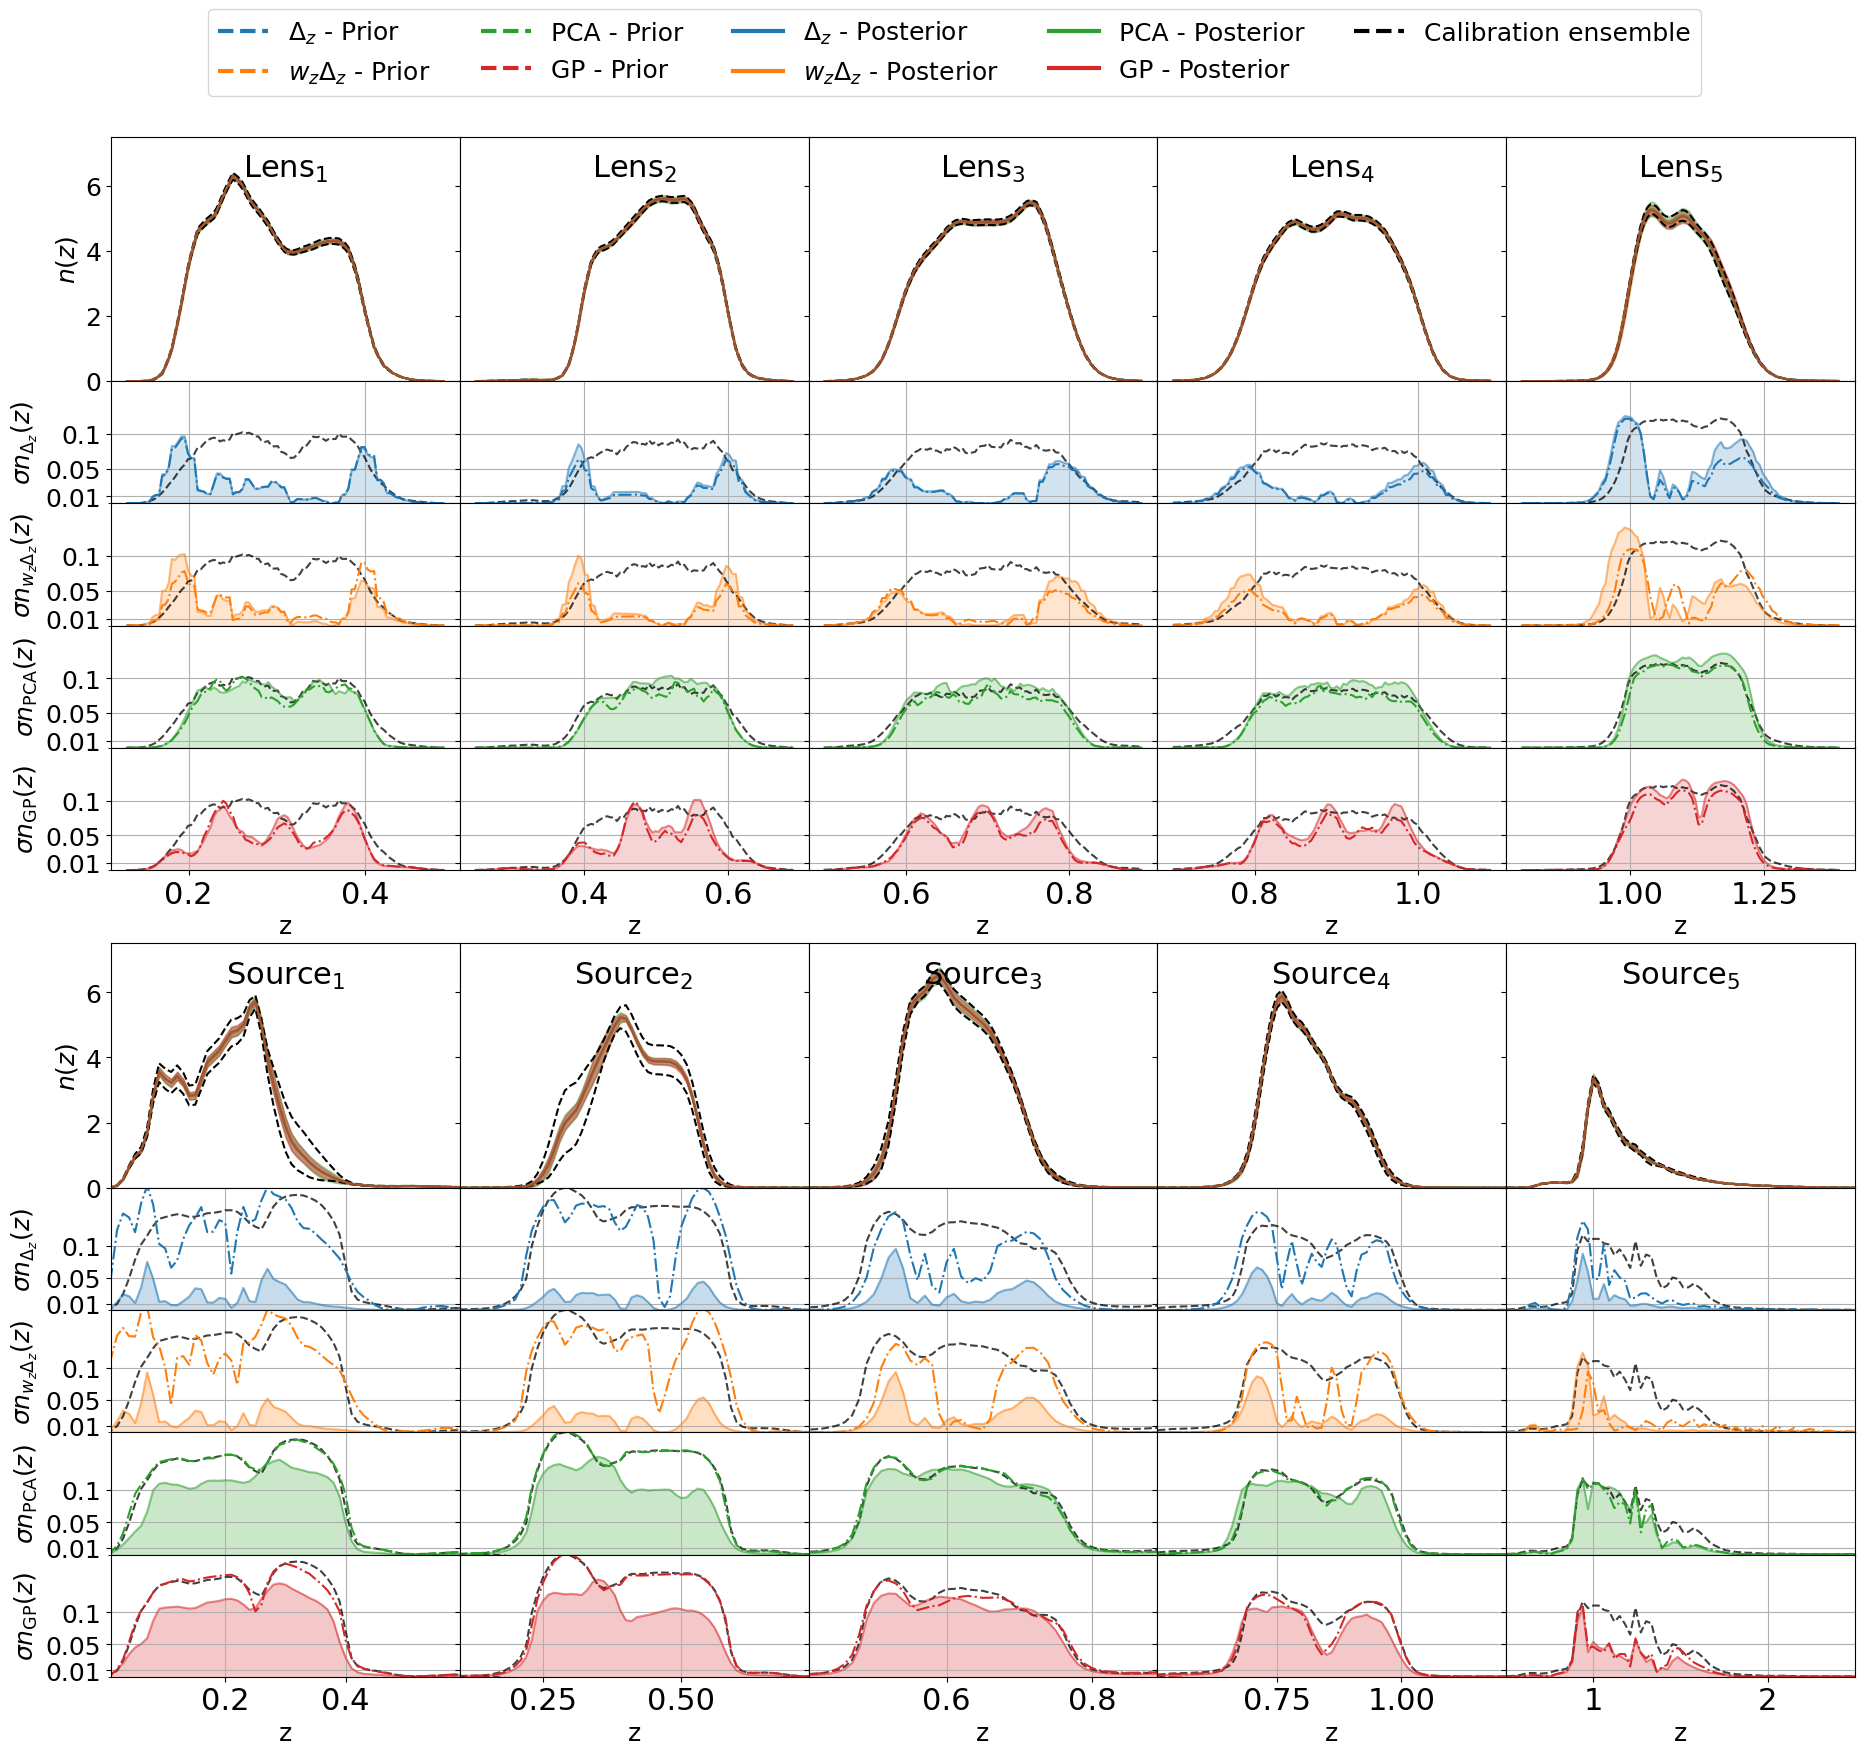

In [30]:
import matplotlib.pyplot as plt
import numpy as np
from matplotlib.gridspec import GridSpec, GridSpecFromSubplotSpec

# --- overall figure ---
fig = plt.figure(figsize=(4.5*5, 20))

# --- global GridSpec: 2 blocks (lens + source) ---
outer_gs = GridSpec(
    2, 1,
    height_ratios=[1, 1],
    hspace=0.1,   # <== bigger space between lens and source blocks
)

# --- lens block (main+diff share x) ---
gs_lens = GridSpecFromSubplotSpec(
    5, 5, subplot_spec=outer_gs[0],
    height_ratios=[1, 0.5, 0.5, 0.5, 0.5],
    hspace=0.00,
    wspace=0.00
)

# --- source block (main+diff share x) ---
gs_source = GridSpecFromSubplotSpec(
    5, 5, subplot_spec=outer_gs[1],
    height_ratios=[1, 0.5, 0.5, 0.5, 0.5],
    hspace=0.00,
    wspace=0.00,
)

axis_main = np.empty((2, 5), dtype=object)
axis_diff = np.empty((8, 5), dtype=object)

for i in range(5):
    # lens pair (sharex)
    axis_main[0, i] = fig.add_subplot(gs_lens[0, i])
    axis_diff[0, i] = fig.add_subplot(gs_lens[1, i], sharex=axis_main[0, i])
    axis_diff[1, i] = fig.add_subplot(gs_lens[2, i], sharex=axis_main[0, i])
    axis_diff[2, i] = fig.add_subplot(gs_lens[3, i], sharex=axis_main[0, i])
    axis_diff[3, i] = fig.add_subplot(gs_lens[4, i], sharex=axis_main[0, i])
    # source pair (sharex)
    axis_main[1, i] = fig.add_subplot(gs_source[0, i])
    axis_diff[4, i] = fig.add_subplot(gs_source[1, i], sharex=axis_main[1, i])
    axis_diff[5, i] = fig.add_subplot(gs_source[2, i], sharex=axis_main[1, i])
    axis_diff[6, i] = fig.add_subplot(gs_source[3, i], sharex=axis_main[1, i])
    axis_diff[7, i] = fig.add_subplot(gs_source[4, i], sharex=axis_main[1, i])

# ================================================================
# === LENS TRACERS
# ================================================================
lens_tracers = ['lens_0', 'lens_1', 'lens_2', 'lens_3', 'lens_4']
for i, t in enumerate(lens_tracers):
    ax = axis_main[0, i]
    z = nzs[t]["z"]

    # --- Main ---
    qs = np.quantile(data_nzs[t], [0.25, 0.5, 0.75], axis=1)
    lq = qs[1]-qs[0]; uq = qs[2]-qs[1]
    ax.plot(z, np.mean(shifts_nzs[t], axis=0)-lq, ls="--", color="k")
    ax.plot(z, np.mean(shifts_nzs[t], axis=0)+uq, ls="--", color="k")
    ax.set_title(rf"${{\rm Lens}}_{i+1}$", y=0.8)

    for model, color, label in [
        (shifts_nzs, "C0", "Shifts"),
        (SnWs_nzs, "C1", "Shifts & Widths"),
        (pca_nzs, "C2", "PCA"),
        (gp_nzs, "C3", "GP"),
    ]:
        qs = np.quantile(model[t], [0.25, 0.5, 0.75], axis=0)
        lq = qs[1]-qs[0]; uq = qs[2]-qs[1]
        m = np.mean(model[t], axis=0)
        ax.plot(z, m, alpha=0.6, color=color, label=label)
        ax.fill_between(z, m-lq, m+uq, alpha=0.4, color=color)

    ax.set_ylim([-0.002, 7.5])
    if i > 0: ax.set_yticklabels([])
    else: ax.set_ylabel(r"$n(z)$")
    plt.setp(ax.get_xticklabels(), visible=False)

    # --- Diff ---
    j = 0
    for model, prior, color, label in [
        (shifts_nzs, dz_prior_nzs, "C0", r"$\sigma n_{\Delta_z}(z)$"),
        (SnWs_nzs, dzwz_prior_nzs, "C1", r"$\sigma n_{w_z \Delta_z}(z)$"),
        (pca_nzs, pca_prior_nzs, "C2", r"$\sigma n_{\rm PCA}(z)$"),
        (gp_nzs, gp_prior_nzs, "C3", r"$\sigma n_{\rm GP}(z)$"),
    ]:
        axd = axis_diff[j, i]
        qs = np.quantile(data_nzs[t], [0.25, 0.5, 0.75], axis=1)
        lq = qs[1]-qs[0]; uq = qs[2]-qs[1]
        axd.plot(z, -lq, ls="--", alpha=0.75, color="k")
        axd.plot(z, uq, ls="--", alpha=0.75, color="k")
        qs = np.quantile(prior[t], [0.25, 0.5, 0.75], axis=1)
        lq = qs[1]-qs[0]; uq = qs[2]-qs[1]
        axd.plot(z, -lq, ls="-.", color=color)
        axd.plot(z, uq, ls="-.", color=color)
        qs = np.quantile(model[t], [0.25, 0.5, 0.75], axis=0)
        lq = qs[1]-qs[0]; uq = qs[2]-qs[1]
        axd.fill_between(z, -lq, uq, alpha=0.2, color=color)
        axd.plot(z, -lq, color=color, alpha=0.5)
        axd.plot(z, uq, color=color, alpha=0.5)
        j += 1
        axd.grid(True)
        axd.set_yscale("symlog", linthresh=0.1)
        axd.set_ylim([-0., 0.7])
        axd.set_yticks([0.01, 0.05, 0.1])
        axd.set_yticklabels([0.01, 0.05, 0.1])
        if i > 0: axd.set_yticklabels([])
        else: axd.set_ylabel(label)
        axd.set_xlabel("z")

# ================================================================
# === SOURCE TRACERS
# ================================================================
xlims = [(0.01, 0.59), (0.1, 0.73), (0.41, 0.89), (0.51, 1.21), (0.5, 2.5)]
source_tracers = ['source_0', 'source_1', 'source_2', 'source_3', 'source_4']
for i, t in enumerate(source_tracers):
    ax = axis_main[1, i]
    z = nzs[t]["z"]

    # --- Main ---
    qs = np.quantile(data_nzs[t], [0.25, 0.5, 0.75], axis=1)
    lq = qs[1]-qs[0]; uq = qs[2]-qs[1]
    ax.plot(z, np.mean(shifts_nzs[t], axis=0)-lq, ls="--", color="k")
    ax.plot(z, np.mean(shifts_nzs[t], axis=0)+uq, ls="--", color="k")
    ax.set_title(rf"${{\rm Source}}_{i+1}$", y=0.8)

    for model, color, label in [
        (shifts_nzs, "C0", "Shifts"),
        (SnWs_nzs, "C1", "Shifts & Widths"),
        (pca_nzs, "C2", "PCA"),
        (gp_nzs, "C3", "GP"),
    ]:
        qs = np.quantile(model[t], [0.25, 0.5, 0.75], axis=0)
        lq = qs[1]-qs[0]; uq = qs[2]-qs[1]
        m = np.mean(model[t], axis=0)
        ax.plot(z, m, alpha=0.6, color=color, label=label)
        ax.fill_between(z, m-lq, m+uq, alpha=0.4, color=color)

    ax.set_ylim([-0.005, 7.5])
    ax.set_xlim(xlims[i])
    if i > 0: ax.set_yticklabels([])
    else: ax.set_ylabel(r"$n(z)$")
    plt.setp(ax.get_xticklabels(), visible=False)

    # --- Diff ---
    j = 4
    for model, prior, color, label in [
        (shifts_nzs, dz_prior_nzs, "C0", r"$\sigma n_{\Delta_z}(z)$"),
        (SnWs_nzs, dzwz_prior_nzs, "C1", r"$\sigma n_{w_z \Delta_z}(z)$"),
        (pca_nzs, pca_prior_nzs, "C2", r"$\sigma n_{\rm PCA}(z)$"),
        (gp_nzs, gp_prior_nzs, "C3", r"$\sigma n_{\rm GP}(z)$"),
    ]:
        axd = axis_diff[j, i]
        qs = np.quantile(data_nzs[t], [0.25, 0.5, 0.75], axis=1)
        lq = qs[1]-qs[0]; uq = qs[2]-qs[1]
        axd.plot(z, -lq, ls="--", alpha=0.75, color="k")
        axd.plot(z, uq, ls="--", alpha=0.75, color="k")
        qs = np.quantile(prior[t], [0.25, 0.5, 0.75], axis=1)
        lq = qs[1]-qs[0]; uq = qs[2]-qs[1]
        axd.plot(z, -lq, ls="-.", color=color)
        axd.plot(z, uq, ls="-.", color=color)
        qs = np.quantile(model[t], [0.25, 0.5, 0.75], axis=0)
        lq = qs[1]-qs[0]; uq = qs[2]-qs[1]
        axd.fill_between(z, -lq, uq, alpha=0.25, color=color)
        axd.plot(z, -lq, color=color, alpha=0.5)
        axd.plot(z, uq, color=color, alpha=0.5)
        j += 1
        axd.grid(True)
        axd.set_yscale("symlog", linthresh=0.1)
        axd.set_ylim([0, 0.99])
        axd.set_yticks([0.01, 0.05, 0.1])
        axd.set_yticklabels([0.01, 0.05, 0.1])
        if i > 0: axd.set_yticklabels([])
        else: axd.set_ylabel(label)
        axd.set_xlabel("z")
        axd.set_xlim(xlims[i])
# ================================================================
# Legend and save
# ================================================================
labels = [r"$\Delta_z$ - Prior", r"$w_z \Delta_z$ - Prior", "PCA - Prior", "GP - Prior",
          r"$\Delta_z$ - Posterior", r"$w_z \Delta_z$ - Posterior", "PCA - Posterior", "GP - Posterior",
           "Calibration ensemble",]
colors = ["C0", "C1", "C2", "C3"]
lines = [plt.Line2D([0], [0], color=color, ls='--', lw=3) for color in colors]
lines += [plt.Line2D([0], [0], color=color, ls='-', lw=3) for color in colors]
lines += [plt.Line2D([0], [0], color='k', ls='--', lw=3)]
fig.legend(lines, labels, ncol=5, loc='upper center', bbox_to_anchor=(0.5, 0.95))

fig.savefig("./paper_plots/Y1_nz_comparison.pdf", bbox_inches='tight')

## Trace plots

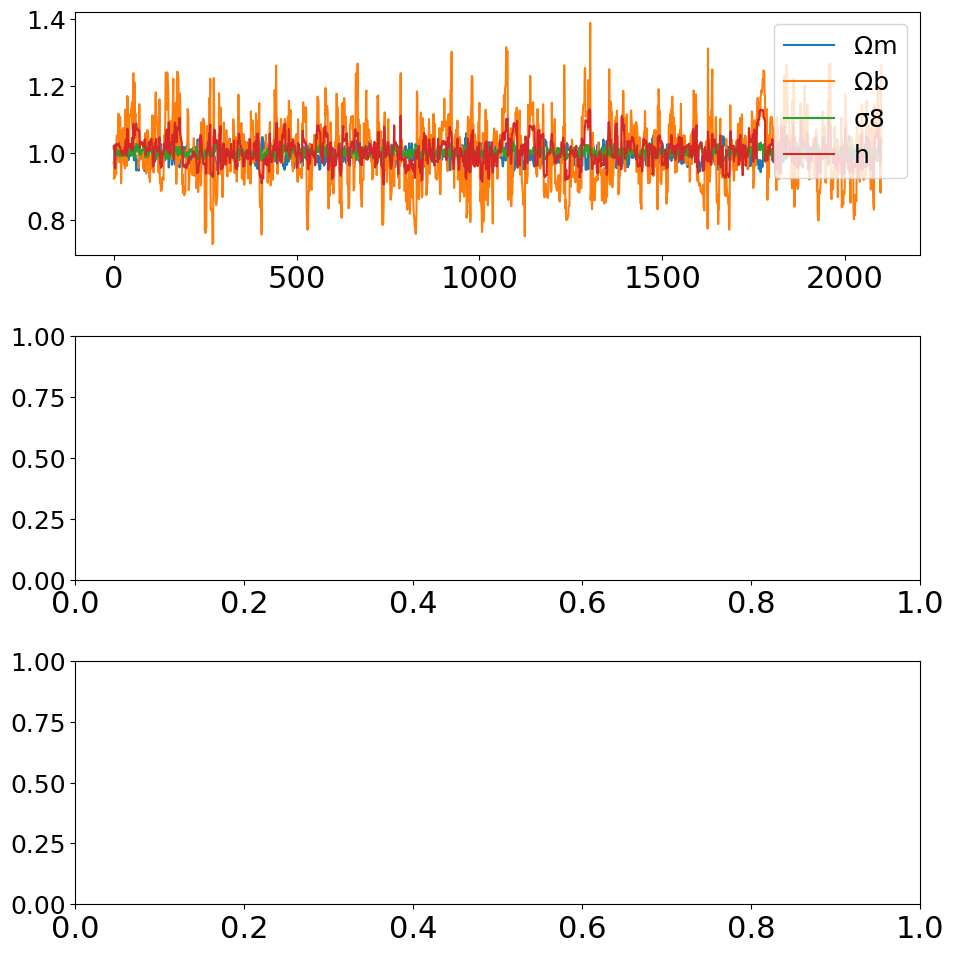

In [31]:
fig, axs = plt.subplots(3, 1, figsize=(10, 10))
chain = chain_Y1_3x2_nomarg
# First plot
axs[0].plot(np.array(chain["Ωm"])/0.27347, label="Ωm")
axs[0].plot(np.array(chain["Ωb"])/0.04217, label="Ωb")
axs[0].plot(np.array(chain["σ8"])/0.779007, label="σ8")
axs[0].plot(np.array(chain["h"])/0.71899, label="h")
axs[0].legend()
# Second plot
#axs[1].plot(np.array(chain_Y1_gcgc_nomarg["Ωm"])/0.27347, label="Ωm")
#axs[1].plot(np.array(chain_Y1_gcgc_nomarg["Ωb"])/0.04217, label="Ωb")
#axs[1].plot(np.array(chain_Y1_gcgc_nomarg["σ8"])/0.779007, label="σ8")
#axs[1].plot(np.array(chain_Y1_gcgc_nomarg["h"])/0.71899, label="h")
#axs[1].legend()
# Second plot
#axs[2].plot(np.array(chain_Y1_wlwl_nomarg["Ωm"])/0.27347, label="Ωm")
#axs[2].plot(np.array(chain_Y1_wlwl_nomarg["Ωb"])/0.04217, label="Ωb")
#axs[2].plot(np.array(chain_Y1_wlwl_nomarg["σ8"])/0.779007, label="σ8")
#axs[2].plot(np.array(chain_Y1_wlwl_nomarg["h"])/0.71899, label="h")
#axs[2].legend()

plt.tight_layout()
plt.show()

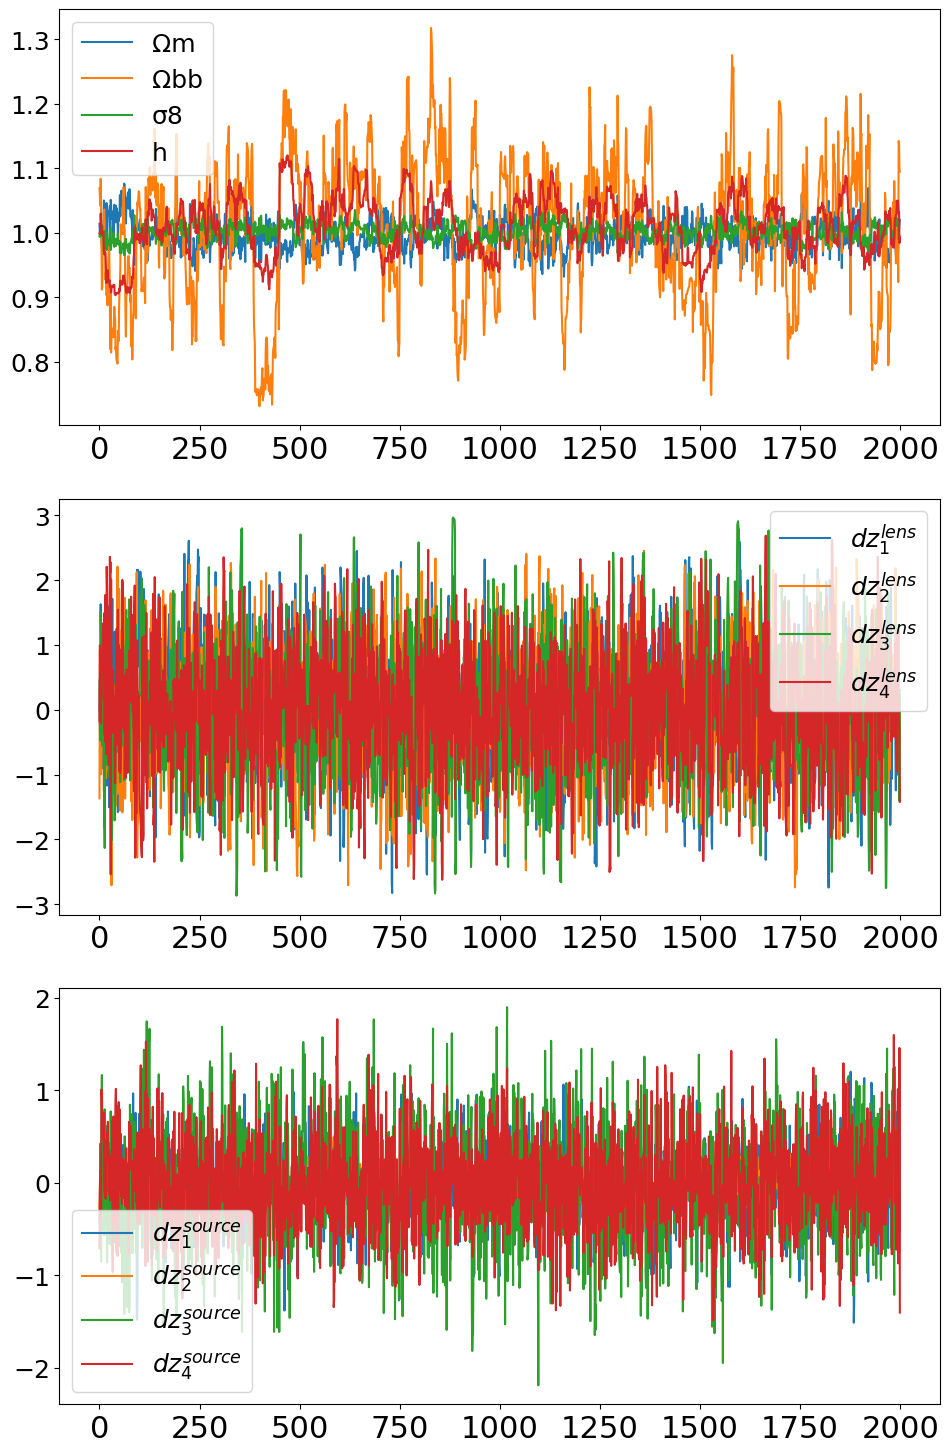

In [32]:
fig, axs = plt.subplots(3, 1, figsize=(10, 15))
chain = chain_Y1_3x2_dz_num
# First plot
axs[0].plot(np.array(chain["Ωm"])/0.27347, label="Ωm")
axs[0].plot(np.array(chain["Ωbb"])/0.4217, label="Ωbb")
axs[0].plot(np.array(chain["σ8"])/0.779007, label="σ8")
axs[0].plot(np.array(chain["h"])/0.71899, label="h")
axs[0].legend()
# Second plot
axs[1].plot(np.array(chain["alphas_lens_0[1]"]), label=r"$dz^{lens}_1$")
axs[1].plot(np.array(chain["alphas_lens_1[1]"]), label=r"$dz^{lens}_2$")
axs[1].plot(np.array(chain["alphas_lens_2[1]"]), label=r"$dz^{lens}_3$")
axs[1].plot(np.array(chain["alphas_lens_3[1]"]), label=r"$dz^{lens}_4$")
axs[1].legend()
# Third plot
axs[2].plot(np.array(chain["alphas_source_0[1]"]), label=r"$dz^{source}_1$")
axs[2].plot(np.array(chain["alphas_source_1[1]"]), label=r"$dz^{source}_2$")
axs[2].plot(np.array(chain["alphas_source_2[1]"]), label=r"$dz^{source}_3$")
axs[2].plot(np.array(chain["alphas_source_3[1]"]), label=r"$dz^{source}_4$")
axs[2].legend()

plt.tight_layout()
plt.show()

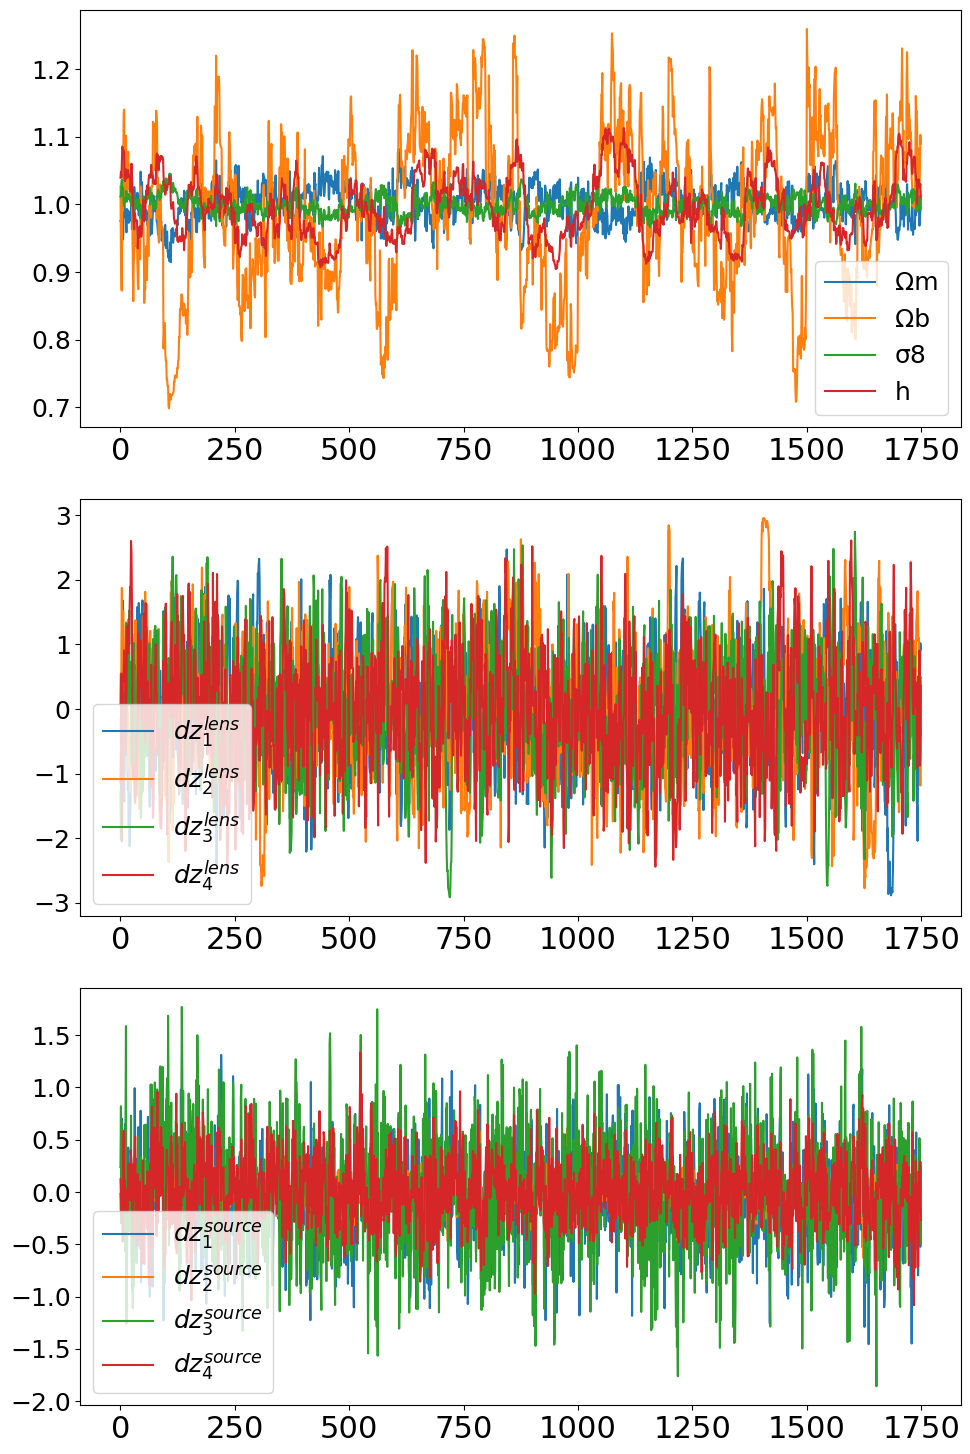

In [33]:
fig, axs = plt.subplots(3, 1, figsize=(10, 15))
chain = chain_Y1_3x2_wzdz_num
# First plot
axs[0].plot(np.array(chain["Ωm"])/0.27347, label="Ωm")
axs[0].plot(np.array(chain["Ωb"])/0.04217, label="Ωb")
axs[0].plot(np.array(chain["σ8"])/0.779007, label="σ8")
axs[0].plot(np.array(chain["h"])/0.71899, label="h")
axs[0].legend()
# Second plot
axs[1].plot(np.array(chain["alphas_lens_0[1]"]), label=r"$dz^{lens}_1$")
axs[1].plot(np.array(chain["alphas_lens_1[1]"]), label=r"$dz^{lens}_2$")
axs[1].plot(np.array(chain["alphas_lens_2[1]"]), label=r"$dz^{lens}_3$")
axs[1].plot(np.array(chain["alphas_lens_3[1]"]), label=r"$dz^{lens}_4$")
axs[1].legend()
# Third plot
axs[2].plot(np.array(chain["alphas_source_0[1]"]), label=r"$dz^{source}_1$")
axs[2].plot(np.array(chain["alphas_source_1[1]"]), label=r"$dz^{source}_2$")
axs[2].plot(np.array(chain["alphas_source_2[1]"]), label=r"$dz^{source}_3$")
axs[2].plot(np.array(chain["alphas_source_3[1]"]), label=r"$dz^{source}_4$")
axs[2].legend()

plt.tight_layout()
plt.show()

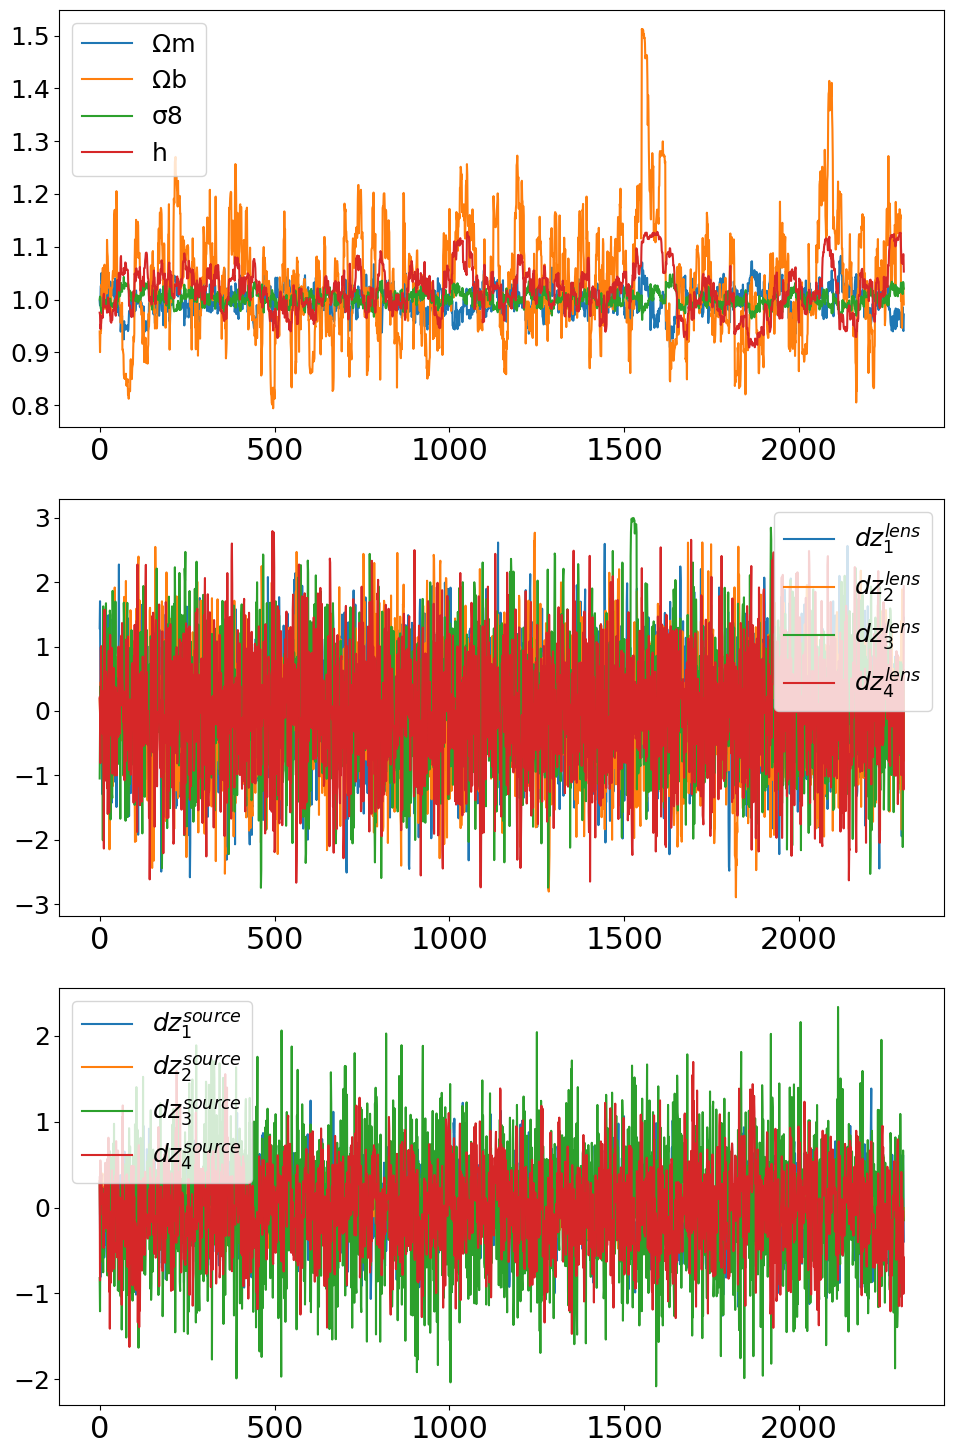

In [34]:
fig, axs = plt.subplots(3, 1, figsize=(10, 15))
chain = chain_Y1_3x2_PCA_num
# First plot
axs[0].plot(np.array(chain["Ωm"])/0.27347, label="Ωm")
axs[0].plot(np.array(chain["Ωb"])/0.04217, label="Ωb")
axs[0].plot(np.array(chain["σ8"])/0.779007, label="σ8")
axs[0].plot(np.array(chain["h"])/0.71899, label="h")
axs[0].legend()
# Second plot
axs[1].plot(np.array(chain["alphas_lens_0[1]"]), label=r"$dz^{lens}_1$")
axs[1].plot(np.array(chain["alphas_lens_1[1]"]), label=r"$dz^{lens}_2$")
axs[1].plot(np.array(chain["alphas_lens_2[1]"]), label=r"$dz^{lens}_3$")
axs[1].plot(np.array(chain["alphas_lens_3[1]"]), label=r"$dz^{lens}_4$")
axs[1].legend()
# Third plot
axs[2].plot(np.array(chain["alphas_source_0[1]"]), label=r"$dz^{source}_1$")
axs[2].plot(np.array(chain["alphas_source_1[1]"]), label=r"$dz^{source}_2$")
axs[2].plot(np.array(chain["alphas_source_2[1]"]), label=r"$dz^{source}_3$")
axs[2].plot(np.array(chain["alphas_source_3[1]"]), label=r"$dz^{source}_4$")
axs[2].legend()

plt.tight_layout()
plt.show()

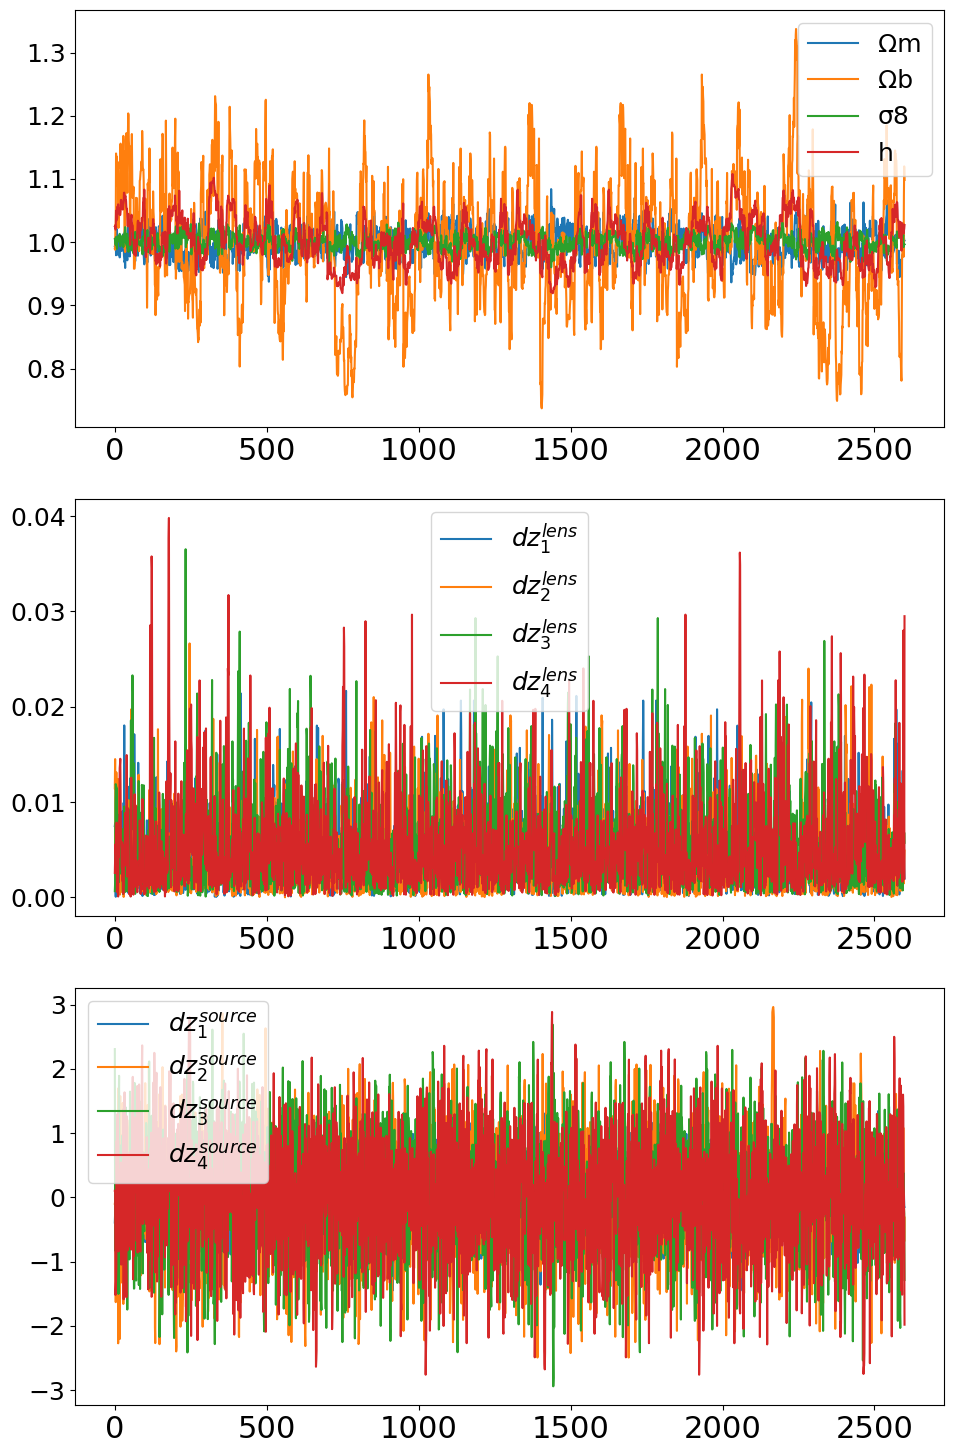

In [35]:
fig, axs = plt.subplots(3, 1, figsize=(10, 15))
chain = chain_Y1_3x2_gp_num
# First plot
axs[0].plot(np.array(chain["Ωm"])/0.27347, label="Ωm")
axs[0].plot(np.array(chain["Ωb"])/0.04217, label="Ωb")
axs[0].plot(np.array(chain["σ8"])/0.779007, label="σ8")
axs[0].plot(np.array(chain["h"])/0.71899, label="h")
axs[0].legend()
# Second plot
axs[1].plot(np.array(chain["dnz_lens_0"]), label=r"$dz^{lens}_1$")
axs[1].plot(np.array(chain["dnz_lens_1"]), label=r"$dz^{lens}_2$")
axs[1].plot(np.array(chain["dnz_lens_2"]), label=r"$dz^{lens}_3$")
axs[1].plot(np.array(chain["dnz_lens_3"]), label=r"$dz^{lens}_4$")
axs[1].legend()
# Third plot
axs[2].plot(np.array(chain["alphas_source_0[1]"]), label=r"$dz^{source}_1$")
axs[2].plot(np.array(chain["alphas_source_1[1]"]), label=r"$dz^{source}_2$")
axs[2].plot(np.array(chain["alphas_source_2[1]"]), label=r"$dz^{source}_3$")
axs[2].plot(np.array(chain["alphas_source_3[1]"]), label=r"$dz^{source}_4$")
axs[2].legend()

plt.tight_layout()
plt.show()

## Posteriors

In [36]:
labels_dict = {'h': 'h',
               'Ωm': r'\Omega_{\rm m}',
               'Ωb': r'\Omega_{\rm b}',
               'ns': r'n_{\rm s}',
               'σ8': r'\sigma_{\rm 8}',
               'S8': r'S_{\rm 8}',

               'lens_b': r'\langle b_{\rm g} \rangle',
               'lens_0_b': r'b_{\rm g}^0',
               'lens_1_b': r'b_{\rm g}^1',
               'lens_2_b': r'b_{\rm g}^2',
               'lens_3_b': r'b_{\rm g}^3',
               'lens_4_b': r'b_{\rm g}^4',

               'dnz_lens': r'\langle \delta n(z)_{lens}\rangle',
               'dnz_lens_0': r'\delta n(z)_{lens^{0}}',
               'dnz_lens_1': r'\delta n(z)_{lens^{1}}',
               'dnz_lens_2': r'\delta n(z)_{lens^{2}}',
               'dnz_lens_3': r'\delta n(z)_{lens^{3}}',
               'dnz_lens_4': r'\delta n(z)_{lens^{4}}',
               'dnz_source': r'\langle \delta n(z)_{source}\rangle',
               'dnz_source_0': r'\delta n(z)_{source^{0}}',
               'dnz_source_1': r'\delta n(z)_{source^{1}}',
               'dnz_source_2': r'\delta n(z)_{source^{2}}',
               'dnz_source_3': r'\delta n(z)_{source^{3}}',
               'dnz_source_4': r'\delta n(z)_{source^{4}}',

               'dz_lens_0': r'\Delta^{0}_{z, lens}',
               'dz_lens_1': r'\Delta^{1}_{z, lens}',
               'dz_lens_2': r'\Delta^{2}_{z, lens}',
               'dz_lens_3': r'\Delta^{3}_{z, lens}',
               'dz_lens_4': r'\Delta^{4}_{z, lens}',
               'dz_source_0': r'\Delta^{0}_{z, source}',
               'dz_source_1': r'\Delta^{1}_{z, source}',
               'dz_source_2': r'\Delta^{2}_{z, source}',
               'dz_source_3': r'\Delta^{3}_{z, source}',
               'dz_source_4': r'\Delta^{4}_{z, source}', 

               'wz_lens_0': r'w^{0}_{z, lens}',
               'wz_lens_1': r'w^{1}_{z, lens}',
               'wz_lens_2': r'w^{2}_{z, lens}',
               'wz_lens_3': r'w^{3}_{z, lens}',
               'wz_lens_4': r'w^{4}_{z, lens}',
               'wz_source_0': r'w^{0}_{z, source}',
               'wz_source_1': r'w^{1}_{z, source}',
               'wz_source_2': r'w^{2}_{z, source}',
               'wz_source_3': r'w^{3}_{z, source}',
               'wz_source_4': r'w^{4}_{z, source}',
               
               'A_IA': 'A_{IA}',
               
               'Xi2': r'\chi^2',}

In [37]:
def make_chain(file, label, ranges=dict({}), weight=False, labels_dict=labels_dict):
    params = np.array(list(file.keys()))
    names = []
    labels = []
    samples = []
    print(label)
    for param in params:
        #print(param)
        if param in labels_dict.keys():
            #print(param)
            names.append(param) 
            labels.append(labels_dict[param]) 
            samples.append(file[param])
    if ('σ8' in params) & ('Ωm' in params):
        #print('S8')
        names.append('S8')
        labels.append(labels_dict['S8'])
        samples.append(file['σ8']*np.sqrt(file['Ωm']/0.3))

    names = np.array(names)
    labels = np.array(labels)
    samples = np.transpose(np.array(samples))
    if weight == True:
        if "log_density" in params:
            print("applying weights")
            ws = np.array(file['log_density'])
    else:
        ws = None
    print("========")

    return MCSamples(samples=samples, names=names, labels=labels, label=label, ranges=ranges, weights=ws,
                    settings={'mult_bias_correction_order':0,'smooth_scale_2D':0.4, 'smooth_scale_1D':0.3})
    

In [38]:
samples_wzdz_prior = make_chain(prior_wzdz_chain, r"Prior", labels_dict=labels_dict)

Prior
Removed no burn in


In [39]:
samples_3x2_Y1_nomarg = make_chain(chain_Y1_3x2_nomarg, "LSSTY1 3x2pt - No model")

samples_3x2_Y1_dz_ana = make_chain(chain_Y1_3x2_dz_ana, r"LSSTY1 3x2pt - $\Delta_z$ Analytical")
samples_3x2_Y1_wzdz_ana = make_chain(chain_Y1_3x2_wzdz_ana, r"LSSTY1 3x2pt - $w_z \, \Delta_z$ Analytical")
samples_3x2_Y1_PCA_ana = make_chain(chain_Y1_3x2_PCA_ana, r"LSSTY1 3x2pt - PCA Analytical")
samples_3x2_Y1_gp_ana = make_chain(chain_Y1_3x2_gp_ana, r"LSSTY1 3x2pt - GP Analytical")

samples_3x2_Y1_dz_num = make_chain(chain_Y1_3x2_dz_num, r"LSSTY1 3x2pt - $\Delta_z$ Numerical")
samples_3x2_Y1_wzdz_num = make_chain(chain_Y1_3x2_wzdz_num, r"LSSTY1 3x2pt - $w_z \, \Delta_z$ Numerical")
samples_3x2_Y1_PCA_num = make_chain(chain_Y1_3x2_PCA_num, r"LSSTY1 3x2pt - PCA Numerical")
samples_3x2_Y1_gp_num = make_chain(chain_Y1_3x2_gp_num, r"LSSTY1 3x2pt - GP Numerical")

#samples_wlwl_Y1_nomarg = make_chain(chain_Y1_wlwl_nomarg, "Y1 Fixed - WLWL")
#samples_gcgc_Y1_nomarg = make_chain(chain_Y1_3x2_nomarg, "Y1 Fixed - GCGC")

LSSTY1 3x2pt - No model
Removed no burn in
LSSTY1 3x2pt - $\Delta_z$ Analytical
Removed no burn in
LSSTY1 3x2pt - $w_z \, \Delta_z$ Analytical
Removed no burn in
LSSTY1 3x2pt - PCA Analytical
Removed no burn in
LSSTY1 3x2pt - GP Analytical
Removed no burn in
LSSTY1 3x2pt - $\Delta_z$ Numerical
Removed no burn in
LSSTY1 3x2pt - $w_z \, \Delta_z$ Numerical
Removed no burn in
LSSTY1 3x2pt - PCA Numerical
Removed no burn in
LSSTY1 3x2pt - GP Numerical
Removed no burn in


In [40]:
prat_markers = {'h': 0.7189925511925751,
               'Ωm': 0.2734714358876248,
               'Ωb': 0.042170616570847225,
               'ns': 0.9965136823002241,
               'σ8': 0.7790071910238021,
               'lens_0_b':0.879118,
               'lens_1_b':1.05894, 
               'lens_2_b':1.22145, 
               'lens_3_b':1.35065, 
               'lens_4_b':1.58909,
               'A_IA':0.25179439}
prat_markers['S8'] = prat_markers['σ8']*np.sqrt(prat_markers['Ωm']/0.3)

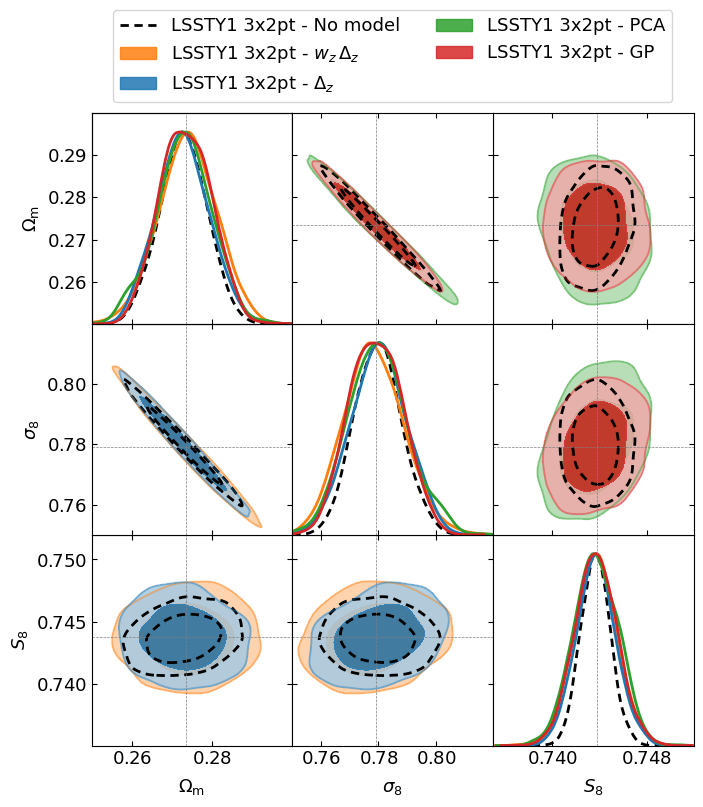

In [41]:
g = plots.getSubplotPlotter(subplot_size=2.5)
g.settings.axes_fontsize = 15
g.settings.legend_fontsize = 15
g.settings.axes_labelsize = 15
g.triangle_plot([samples_3x2_Y1_nomarg,
                samples_3x2_Y1_wzdz_num,
                samples_3x2_Y1_dz_num,
                 ],
                 ['Ωm', 'σ8', 'S8'],
                 upper_roots = [samples_3x2_Y1_nomarg,
                                samples_3x2_Y1_PCA_num,
                                samples_3x2_Y1_gp_num,
                                ],
                 upper_kwargs = {'contour_colors':['black', 'C2', 'C3'],
                                'contour_ls': ['--', '-', '-'], 
                                    'filled': [False, True, True],
                                    'contour_lws':2}, 
                line_args=[{'color':'black'},
                           {'color':'C1'},
                           {'color':'C0'}], 
                colors=["black", 'C1', 'C0'],
                param_limits={'Ωm':(0.25, 0.3), 'σ8':(0.75, 0.82), 'S8':(0.735, 0.752)},
                filled=[False, True, True],
                contour_ls=['--', '-', '-'], 
                contour_lws=2,
                legend_ncol=2,
                 markers=prat_markers, 
                 legend_labels= [r"LSSTY1 3x2pt - No model",
                          r"LSSTY1 3x2pt - $w_z \, \Delta_z$",
                          r"LSSTY1 3x2pt - $\Delta_z$",
                            r"LSSTY1 3x2pt - PCA",
                            r"LSSTY1 3x2pt - GP"
                          ],)
g.export("./paper_plots/Y1_triangle_comp.pdf")

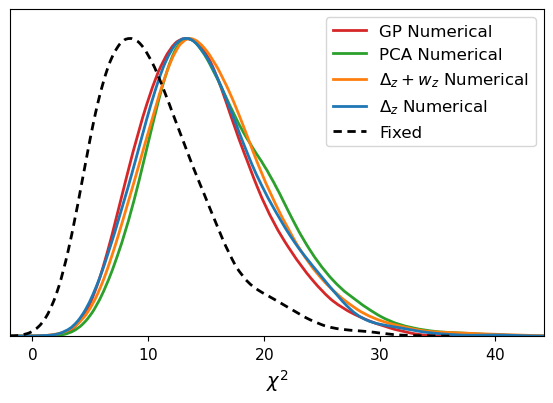

In [42]:
g = plots.get_single_plotter(width_inch=6)
g.plot_1d([
    samples_3x2_Y1_dz_num,
    samples_3x2_Y1_wzdz_num,
    samples_3x2_Y1_PCA_num,
    samples_3x2_Y1_gp_num,
    samples_3x2_Y1_nomarg,
    ], 'Xi2', 
    colors=['C3', 'C2', 'C1', 'C0', "black"],
    ls=['-', '-', '-', '-', '--'], 
    lws=2)
g.add_legend(['GP Numerical', 'PCA Numerical', r'$\Delta_z + w_z$ Numerical', r'$\Delta_z$ Numerical', 'Fixed'])

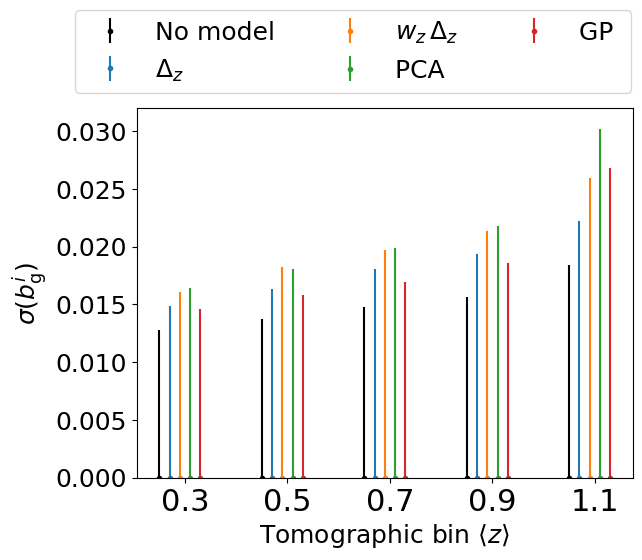

In [43]:
zarr = [0.3, 0.5, 0.7, 0.9, 1.1]
chains = [chain_Y1_3x2_nomarg,
          chain_Y1_3x2_dz_num,
          chain_Y1_3x2_wzdz_num,
          chain_Y1_3x2_PCA_num,
          chain_Y1_3x2_gp_num,
          ]
e = -0.05
colors = ['black', 'C0', 'C1', 'C2', 'C3']
labels = ['No model', r'$\Delta_z$ ', r'$w_z \, \Delta_z$ ', 'PCA ',  'GP ']
for i, chain in enumerate(chains):
    lens_b_1_m, lens_b_1_s = np.mean(chain['lens_0_b']), np.std(chain['lens_0_b'])
    lens_b_2_m, lens_b_2_s = np.mean(chain['lens_1_b']), np.std(chain['lens_1_b'])
    lens_b_3_m, lens_b_3_s = np.mean(chain['lens_2_b']), np.std(chain['lens_2_b'])
    lens_b_4_m, lens_b_4_s = np.mean(chain['lens_3_b']), np.std(chain['lens_3_b'])
    lens_b_5_m, lens_b_5_s = np.mean(chain['lens_4_b']), np.std(chain['lens_4_b'])
    means = np.array([lens_b_1_m, lens_b_2_m, lens_b_3_m, lens_b_4_m, lens_b_5_m])
    errs = np.array([lens_b_1_s, lens_b_2_s, lens_b_3_s, lens_b_4_s, lens_b_5_s])
    mean = np.mean(means)
    #errs /= means
    #means /= means
    color = colors[i]
    label = labels[i]
    plt.errorbar(np.array(zarr)+e, np.zeros_like(means), yerr=errs, fmt='.', color=color, label=label)
    plt.xticks(zarr)
    plt.xlabel(r'Tomographic bin $\langle z \rangle$')
    plt.ylabel(r'$\sigma (b_{\rm g}^i)$')
    plt.legend(ncols=3, bbox_to_anchor=(-0.15, 1.3), loc='upper left')
    plt.ylim(0, 0.032)
    e += 0.02
plt.savefig("./paper_plots/Y1_lens_bias_comp.pdf", bbox_inches='tight', pad_inches=0.1)

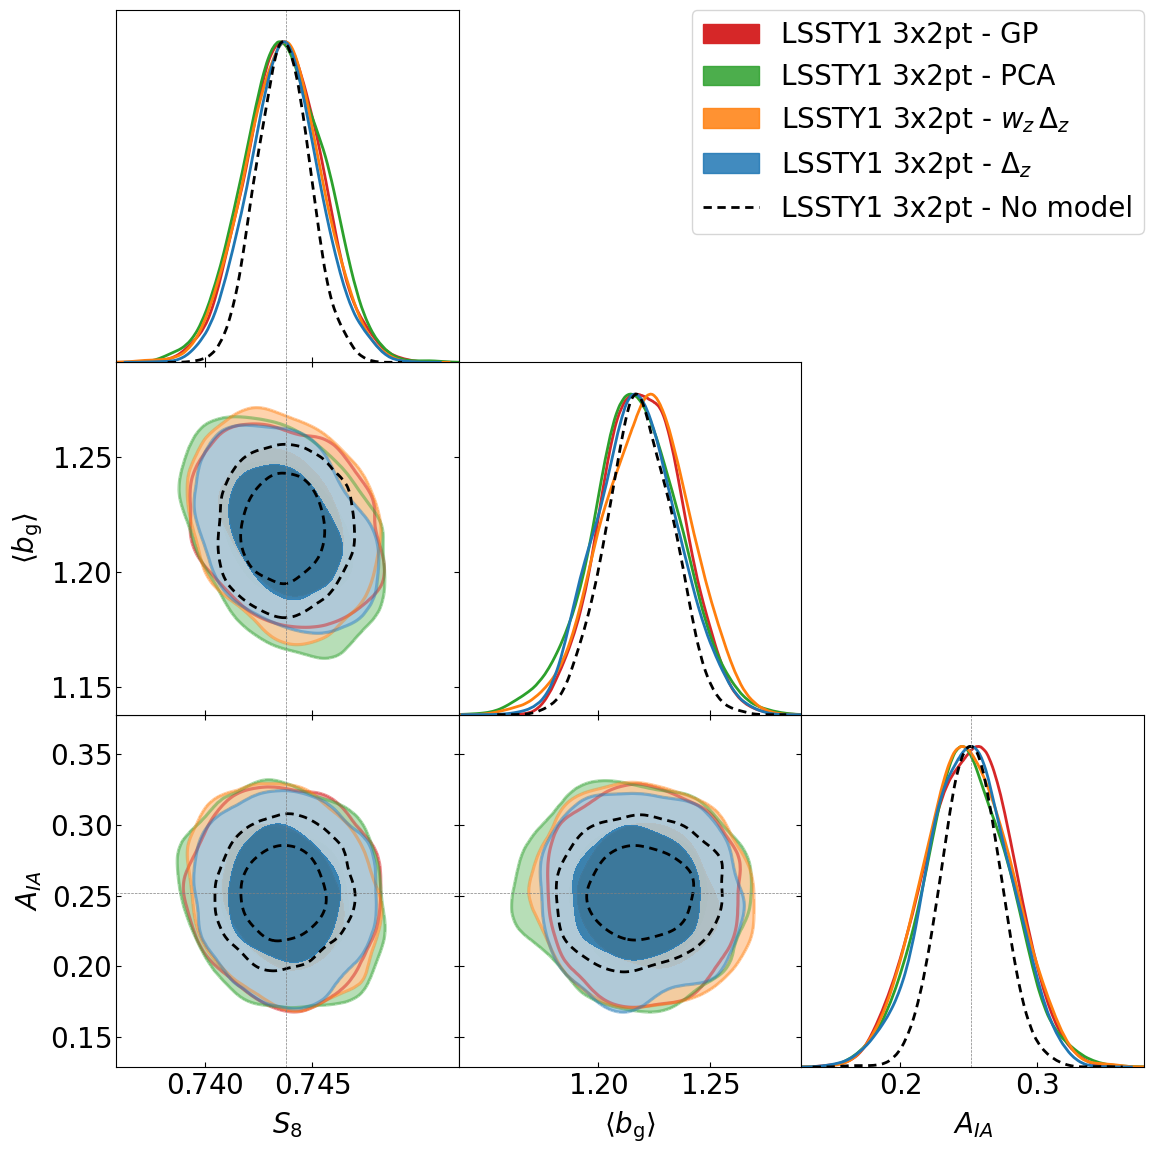

In [44]:
g = plots.getSubplotPlotter(subplot_size=4)
g.settings.axes_fontsize = 20
g.settings.legend_fontsize = 20
g.settings.axes_labelsize = 20
g.triangle_plot([
    samples_3x2_Y1_gp_num,
    samples_3x2_Y1_PCA_num,
    samples_3x2_Y1_wzdz_num,
    samples_3x2_Y1_dz_num,
    samples_3x2_Y1_nomarg,
    ],
    ['S8',
     'lens_b',
     'A_IA',
     #'lens_0_b',
     #'lens_1_b',
     #'lens_2_b',
     #'lens_3_b',
     #'lens_4_b',
],
    line_args=[
            {'color':'C3'},
            {'color':'C2'},
            {'color':'C1'},
            {'color':'C0'},
            {'color':'black'}], 
    colors=['C3', 'C2', 'C1', 'C0', "black"],
    #param_limits={'S8':(0.65, 0.8), 
    #            'lens_0_b':(0.6, 1.3),
    #            'lens_1_b':(0.7, 1.6),
    #            'lens_2_b':(0.8, 1.8),
    #            'lens_3_b':(0.8, 2.1),
    #            'lens_4_b':(1., 2.2),
    #            },
    filled=[True, True, True, True, False],
    contour_ls=['-', '-', '-', '-', '--'], 
    contour_lws=2,
    markers=prat_markers,
    legend_labels= [
        r"LSSTY1 3x2pt - GP",
        r"LSSTY1 3x2pt - PCA",
        r"LSSTY1 3x2pt - $w_z \, \Delta_z$",
        r"LSSTY1 3x2pt - $\Delta_z$",
        r"LSSTY1 3x2pt - No model",
        ],)
g.export("./paper_plots/Y1_triangle_bias.pdf")

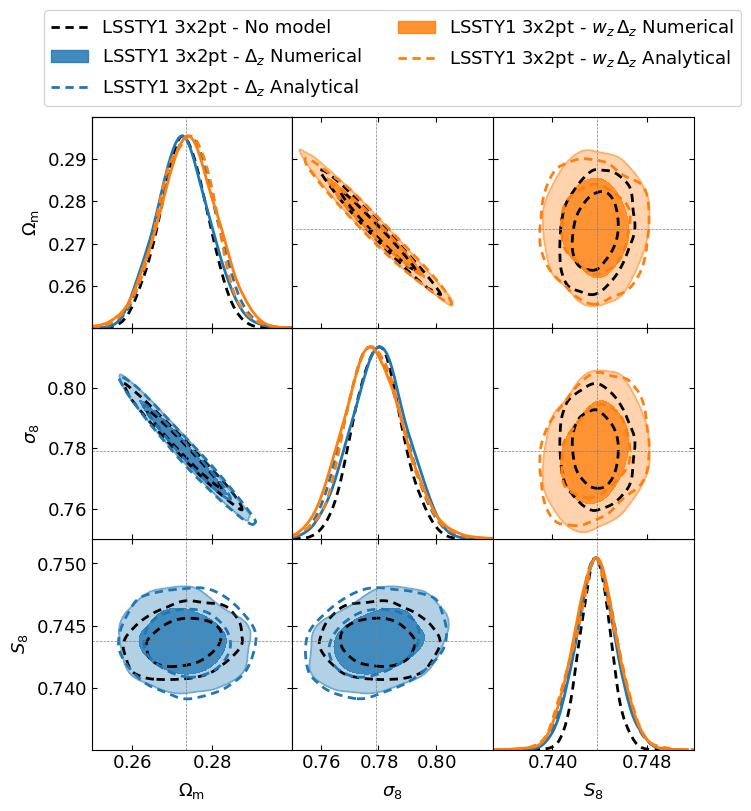

In [45]:
g = plots.getSubplotPlotter(subplot_size=2.5)
g.settings.axes_fontsize = 15
g.settings.legend_fontsize = 15
g.settings.axes_labelsize = 15
g.triangle_plot([samples_3x2_Y1_nomarg,
                samples_3x2_Y1_dz_num,
                samples_3x2_Y1_dz_ana,
                 ],
                 ['Ωm', 'σ8', 'S8'],
                 upper_roots = [samples_3x2_Y1_nomarg,
                                samples_3x2_Y1_wzdz_num,
                                samples_3x2_Y1_wzdz_ana,
                                ],
                 upper_kwargs = {'contour_colors':['black', 'C1', 'C1'],
                                'contour_ls': ['--', '-', '--'], 
                                    'filled': [False, True, False],
                                    'contour_lws':2}, 
                line_args=[{'color':'black'},
                           {'color':'C0'},
                           {'color':'C0'}], 
                colors=["black", 'C0', 'C0'],
                param_limits={'Ωm':(0.25, 0.3), 'σ8':(0.75, 0.82), 'S8':(0.735, 0.752)},
                filled=[False, True, False],
                contour_ls=['--', '-', '--'], 
                contour_lws=2,
                legend_ncol=2,
                 markers=prat_markers)
g.export("./paper_plots/Y1_triangle_1.pdf")

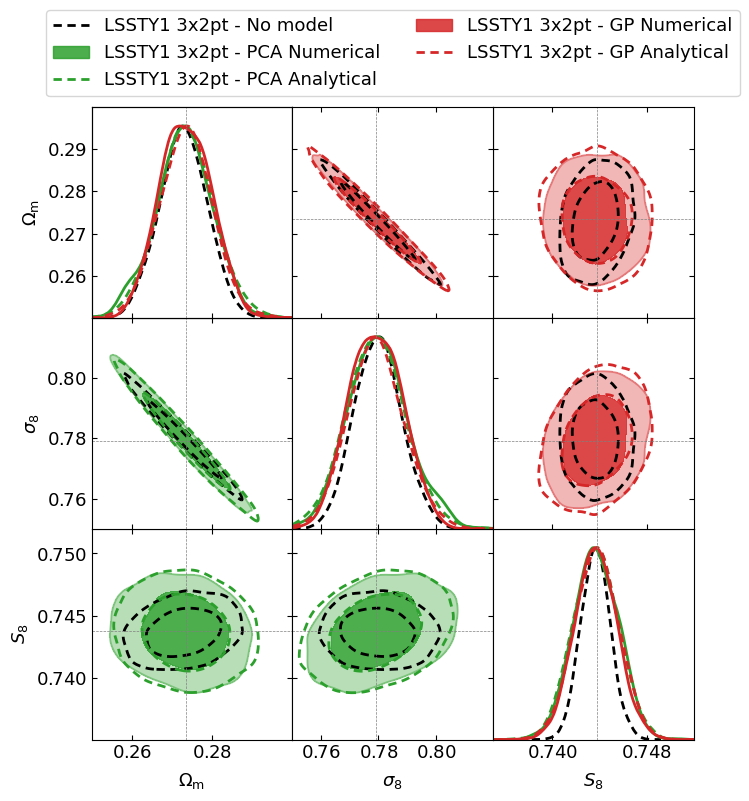

In [46]:
g = plots.getSubplotPlotter(subplot_size=2.5)
g.settings.axes_fontsize = 15
g.settings.legend_fontsize = 15
g.settings.axes_labelsize = 15
g.triangle_plot([samples_3x2_Y1_nomarg,
                 samples_3x2_Y1_PCA_num,
                 samples_3x2_Y1_PCA_ana,
                 ],
                 ['Ωm', 'σ8', 'S8'],
                 upper_roots = [samples_3x2_Y1_nomarg,
                                samples_3x2_Y1_gp_num,
                                samples_3x2_Y1_gp_ana,
                                ],
                 upper_kwargs = {'contour_colors':['black', 'C3', 'C3'],
                                'contour_ls': ['--', '-', '--'], 
                                    'filled': [False, True, False],
                                    'contour_lws':2}, 
                line_args=[{'color':'black'},
                           {'color':'C2'},
                           {'color':'C2'}], 
                colors=["black", 'C2', 'C2'],
                param_limits={'Ωm':(0.25, 0.3), 'σ8':(0.75, 0.82), 'S8':(0.735, 0.752)},
                filled=[False, True, False],
                contour_ls=['--', '-', '--'], 
                contour_lws=2,
                legend_ncol=2,
                 markers=prat_markers)
g.export("./paper_plots/Y1_triangle_2.pdf")

In [47]:
S8_nomarg = chain_Y1_3x2_nomarg["σ8"] * np.sqrt(chain_Y1_3x2_nomarg["Ωm"] / 0.3)
S8_dz_num = chain_Y1_3x2_dz_num["σ8"] * np.sqrt(chain_Y1_3x2_dz_num["Ωm"] / 0.3)
S8_wzdz_num = chain_Y1_3x2_wzdz_num["σ8"] * np.sqrt(chain_Y1_3x2_wzdz_num["Ωm"] / 0.3) 
S8_PCA_num = chain_Y1_3x2_PCA_num["σ8"] * np.sqrt(chain_Y1_3x2_PCA_num["Ωm"] / 0.3)
S8_gp_num = chain_Y1_3x2_gp_num["σ8"]  * np.sqrt(chain_Y1_3x2_gp_num["Ωm"] / 0.3)

print("S8 nomarg: ", np.round(np.mean(S8_nomarg), 4), "+/-", np.round(np.std(S8_nomarg), 4))
print("S8 dz num: ", np.round(np.mean(S8_dz_num), 4), "+/-", np.round(np.std(S8_dz_num), 4))
print("S8 wzdz num: ", np.round(np.mean(S8_wzdz_num), 4), "+/-", np.round(np.std(S8_wzdz_num), 4))
print("S8 PCA num: ", np.round(np.mean(S8_PCA_num), 4), "+/-", np.round(np.std(S8_PCA_num), 4))
print("S8 gp num: ", np.round(np.mean(S8_gp_num), 4), "+/-", np.round(np.std(S8_gp_num), 4))

S8 nomarg:  0.7437 +/- 0.0012
S8 dz num:  0.7437 +/- 0.0016
S8 wzdz num:  0.7436 +/- 0.0017
S8 PCA num:  0.7437 +/- 0.0018
S8 gp num:  0.7437 +/- 0.0017


In [89]:
bias_Ωm_dz = 0.00103119
bias_Ωm_wzdz = 0.000809481
bias_Ωm_PCA = 0.000479724
bias_Ωm_GP = 0.000810802
bias_σ8_dz = 0.00168342
bias_σ8_wzdz = 0.00120074
bias_σ8_PCA = 0.000659139
bias_σ8_GP = 0.000750917
bias_S8_dz = 0.000566786
bias_S8_wzdz = 0.000642766
bias_S8_PCA = 0.000491701
bias_S8_GP = 0.0011113
bv_Ωm_dz = 100 * (bias_Ωm_dz/np.std(chain_Y1_3x2_dz_num["Ωm"]))
bv_Ωm_wzdz = 100 * (bias_Ωm_wzdz/np.std(chain_Y1_3x2_wzdz_num["Ωm"]))
bv_Ωm_PCA = 100 * (bias_Ωm_PCA/np.std(chain_Y1_3x2_PCA_num["Ωm"]))
bv_Ωm_GP = 100 * (bias_Ωm_GP/np.std(chain_Y1_3x2_gp_num["Ωm"]))
bv_σ8_dz = 100 * (bias_σ8_dz/np.std(chain_Y1_3x2_dz_num["σ8"]))
bv_σ8_wzdz = 100 * (bias_σ8_wzdz/np.std(chain_Y1_3x2_wzdz_num["σ8"]))
bv_σ8_PCA = 100 * (bias_σ8_PCA/np.std(chain_Y1_3x2_PCA_num["σ8"]))
bv_σ8_GP = 100 * (bias_σ8_GP/np.std(chain_Y1_3x2_gp_num["σ8"]))
bv_S8_dz = 100 * (bias_S8_dz/np.std(chain_Y1_3x2_dz_num["σ8"] * np.sqrt(chain_Y1_3x2_dz_num["Ωm"] / 0.3)))
bv_S8_wzdz = 100 * (bias_S8_wzdz/np.std(chain_Y1_3x2_wzdz_num["σ8"] * np.sqrt(chain_Y1_3x2_wzdz_num["Ωm"] / 0.3)))
bv_S8_PCA = 100 * (bias_S8_PCA/np.std(chain_Y1_3x2_PCA_num["σ8"] * np.sqrt(chain_Y1_3x2_PCA_num["Ωm"] / 0.3)))
bv_S8_GP = 100 * (bias_S8_GP/np.std(chain_Y1_3x2_gp_num["σ8"] * np.sqrt(chain_Y1_3x2_gp_num["Ωm"] / 0.3)))

print(bv_Ωm_dz, bv_σ8_dz, bv_S8_dz)
print(bv_Ωm_wzdz, bv_σ8_wzdz, bv_S8_wzdz)
print(bv_Ωm_PCA, bv_σ8_PCA, bv_S8_PCA)
print(bv_Ωm_GP, bv_σ8_GP, bv_S8_GP)


16.23652059301606 17.974709739449448 34.77969106199005
11.524663568194251 11.807387754970538 37.01619710275908
7.02870968808271 6.453215749226171 26.602309007114123
13.166504012107483 8.39224667807612 63.74483136553305


/tmp/ipykernel_18760/1986101572.py:36: UserWarning: No artists with labels found to put in legend.  Note that artists whose label start with an underscore are ignored when legend() is called with no argument.
  ax[0].legend(fontsize=11, frameon=False)


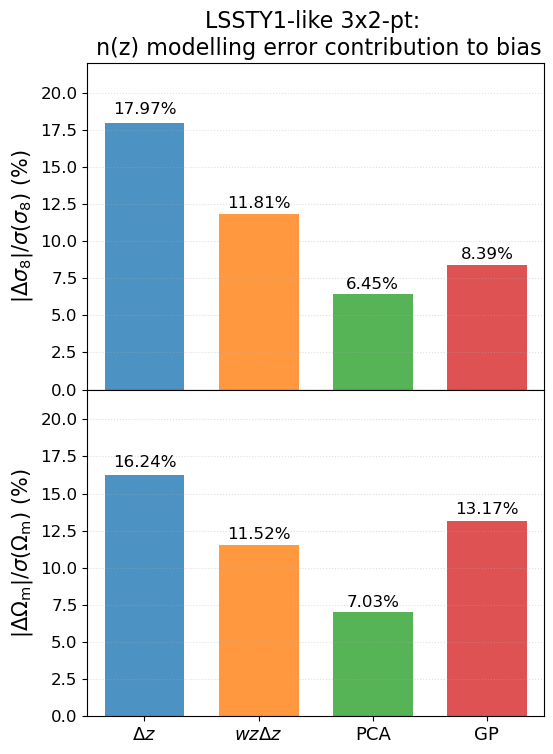

In [86]:
# Prepare data
methods = [r'$\Delta z$', r'$wz\Delta z$', 'PCA', 'GP']
colors = ['C0', 'C1', 'C2', 'C3']

# Compute bias over variance
bvs = [bv_σ8_dz, bv_σ8_wzdz, bv_σ8_PCA, bv_σ8_GP]


# --------------------------------------------
# Plot setup: two bars per method (num vs ana)
# --------------------------------------------
fig, ax = plt.subplots(2, 1, figsize=(6, 8), gridspec_kw={'hspace': 0.0})

xpos = np.arange(len(methods))
bar_width = 0.35

# Plot numerical (solid) and analytical (transparent)
bars_num = ax[0].bar(xpos, bvs, width=2*bar_width,
                  color=colors, alpha=0.8,)

# Aesthetics
ax[0].set_xticks(xpos)
ax[0].set_xticklabels(methods, fontsize=13)
ax[0].set_ylabel(r'$|\Delta\sigma_8|/\sigma(\sigma_8)$ (%)', fontsize=15)
ax[0].tick_params(axis='y', labelsize=12)
ax[0].grid(axis='y', linestyle=':', alpha=0.4)
ax[0].set_xlim(-0.5, len(methods)-0.5)
ax[0].set_ylim(0, 22)    

# Annotate values above bars
for x, s in zip(xpos, bvs):
    if not np.isnan(s):
        ax[0].text(x, s * 1.02, f"{s:.2f}%", ha='center', va='bottom', fontsize=12)

# Legend & title
ax[0].legend(fontsize=11, frameon=False)
ax[0].set_title("LSSTY1-like 3x2-pt: \n n(z) modelling error contribution to bias", fontsize=16)

# Compute bias over variance
bvs = [bv_Ωm_dz, bv_Ωm_wzdz, bv_Ωm_PCA, bv_Ωm_GP]
# Plot numerical (solid) and analytical (transparent)
bars_num = ax[1].bar(xpos, bvs, width=2*bar_width,
                  color=colors, alpha=0.8,)

# Aesthetics
ax[1].set_xticks(xpos)
ax[1].set_xticklabels(methods, fontsize=13)
ax[1].set_ylabel(r'$|\Delta\Omega_{\rm m}|/\sigma(\Omega_{\rm m})$ (%)', fontsize=15)
ax[1].tick_params(axis='y', labelsize=12)
ax[1].grid(axis='y', linestyle=':', alpha=0.4)
ax[1].set_xlim(-0.5, len(methods)-0.5)
ax[1].set_ylim(0, 22)    

# Annotate values above bars
for x, s in zip(xpos, bvs):
    if not np.isnan(s):
        ax[1].text(x, s * 1.02, f"{s:.2f}%", ha='center', va='bottom', fontsize=12)

plt.tight_layout()
plt.savefig("./paper_plots/Y1_bv_comp.pdf", bbox_inches='tight', pad_inches=0)

In [83]:
def make_table(params):
    for param in params:
        if param == "S8":
            param_nomarg = chain_Y1_3x2_nomarg["σ8"] * np.sqrt(chain_Y1_3x2_nomarg["Ωm"] / 0.3)
            param_dz_ana = chain_Y1_3x2_dz_ana["σ8"] * np.sqrt(chain_Y1_3x2_dz_ana["Ωm"] / 0.3)
            param_wzdz_ana = chain_Y1_3x2_wzdz_ana["σ8"] * np.sqrt(chain_Y1_3x2_wzdz_ana["Ωm"] / 0.3)
            param_PCA_ana = chain_Y1_3x2_PCA_ana["σ8"] * np.sqrt(chain_Y1_3x2_PCA_ana["Ωm"] / 0.3)
            param_gp_ana = chain_Y1_3x2_gp_ana["σ8"] * np.sqrt(chain_Y1_3x2_gp_ana["Ωm"] / 0.3)
            param_dz_num = chain_Y1_3x2_dz_num["σ8"] * np.sqrt(chain_Y1_3x2_dz_num["Ωm"] / 0.3)
            param_wzdz_num = chain_Y1_3x2_wzdz_num["σ8"] * np.sqrt(chain_Y1_3x2_wzdz_num["Ωm"] / 0.3) 
            param_PCA_num = chain_Y1_3x2_PCA_num["σ8"] * np.sqrt(chain_Y1_3x2_PCA_num["Ωm"] / 0.3)
            param_gp_num = chain_Y1_3x2_gp_num["σ8"]  * np.sqrt(chain_Y1_3x2_gp_num["Ωm"] / 0.3)
        else:
            param_nomarg = chain_Y1_3x2_nomarg[param]
            param_dz_ana = chain_Y1_3x2_dz_ana[param]
            param_wzdz_ana = chain_Y1_3x2_wzdz_ana[param]
            param_PCA_ana = chain_Y1_3x2_PCA_ana[param]
            param_gp_ana = chain_Y1_3x2_gp_ana[param]
            param_dz_num = chain_Y1_3x2_dz_num[param]
            param_wzdz_num = chain_Y1_3x2_wzdz_num[param]
            param_PCA_num = chain_Y1_3x2_PCA_num[param]
            param_gp_num = chain_Y1_3x2_gp_num[param]

        p = 2
        print("\\multirow{ 2 }{*} {$ \sigma(", labels_dict[param], "^{\\rm model})/\sigma(", labels_dict[param], "^{\\rm no \\, model})$}",
            "&", np.round(100*(np.std(param_dz_num)/np.std(param_nomarg)-1),p),
            "&", np.round(100*(np.std(param_wzdz_num)/np.std(param_nomarg)-1),p),
            "&", np.round(100*(np.std(param_PCA_num)/np.std(param_nomarg)-1),p),
            "&", np.round(100*(np.std(param_gp_num)/np.std(param_nomarg)-1),p),
            "\\\\")
        print(
            "&", np.round(100*(np.std(param_dz_ana)/np.std(param_nomarg)-1),p),
            "&", np.round(100*(np.std(param_wzdz_ana)/np.std(param_nomarg)-1),p),
            "&", np.round(100*(np.std(param_PCA_ana)/np.std(param_nomarg)-1),p),
            "&", np.round(100*(np.std(param_gp_ana)/np.std(param_nomarg)-1),p),
            "\\\\")
        print("\\hline")

<>:25: SyntaxWarning: invalid escape sequence '\s'
<>:25: SyntaxWarning: invalid escape sequence '\s'
<>:25: SyntaxWarning: invalid escape sequence '\s'
<>:25: SyntaxWarning: invalid escape sequence '\s'
/tmp/ipykernel_18760/664121166.py:25: SyntaxWarning: invalid escape sequence '\s'
  print("\\multirow{ 2 }{*} {$ \sigma(", labels_dict[param], "^{\\rm model})/\sigma(", labels_dict[param], "^{\\rm no \\, model})$}",
/tmp/ipykernel_18760/664121166.py:25: SyntaxWarning: invalid escape sequence '\s'
  print("\\multirow{ 2 }{*} {$ \sigma(", labels_dict[param], "^{\\rm model})/\sigma(", labels_dict[param], "^{\\rm no \\, model})$}",


In [84]:
make_table(["Ωm", "σ8", "S8", "Ωb", "h", "ns", "A_IA", "lens_0_b", "lens_1_b", "lens_2_b", "lens_3_b", "lens_4_b"])

\multirow{ 2 }{*} {$ \sigma( \Omega_{\rm m} ^{\rm model})/\sigma( \Omega_{\rm m} ^{\rm no \, model})$} & 11.52 & 23.33 & 19.84 & 8.13 \\
& 14.6 & 13.89 & 20.09 & 12.43 \\
\hline
\multirow{ 2 }{*} {$ \sigma( \sigma_{\rm 8} ^{\rm model})/\sigma( \sigma_{\rm 8} ^{\rm no \, model})$} & 17.82 & 27.93 & 28.5 & 12.56 \\
& 20.39 & 20.24 & 27.44 & 18.81 \\
\hline
\multirow{ 2 }{*} {$ \sigma( S_{\rm 8} ^{\rm model})/\sigma( S_{\rm 8} ^{\rm no \, model})$} & 33.54 & 42.29 & 51.46 & 42.86 \\
& 39.37 & 47.1 & 53.53 & 49.39 \\
\hline
\multirow{ 2 }{*} {$ \sigma( \Omega_{\rm b} ^{\rm model})/\sigma( \Omega_{\rm b} ^{\rm no \, model})$} & 4.0 & 14.74 & 7.61 & -1.36 \\
& 5.8 & -0.93 & 3.86 & 1.27 \\
\hline
\multirow{ 2 }{*} {$ \sigma( h ^{\rm model})/\sigma( h ^{\rm no \, model})$} & 7.31 & 10.4 & 6.92 & -8.84 \\
& 6.27 & 10.37 & 10.69 & 4.26 \\
\hline
\multirow{ 2 }{*} {$ \sigma( n_{\rm s} ^{\rm model})/\sigma( n_{\rm s} ^{\rm no \, model})$} & 10.28 & 12.46 & 13.04 & 8.28 \\
& 14.37 & 12.2 & 13.95 & 

/tmp/ipykernel_18760/1776339718.py:62: UserWarning: No artists with labels found to put in legend.  Note that artists whose label start with an underscore are ignored when legend() is called with no argument.
  ax.legend(fontsize=11, frameon=False)


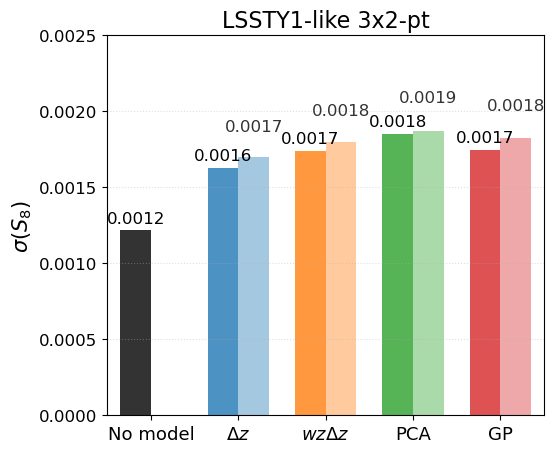

In [53]:
import matplotlib.pyplot as plt
import numpy as np

# Prepare data
methods = ['No model', r'$\Delta z$', r'$wz\Delta z$', 'PCA', 'GP']
colors = ['k', 'C0', 'C1', 'C2', 'C3'] 
def compute_sigma(chain, param='σ8'):
    p = chain[param] * np.sqrt(chain["Ωm"] / 0.3)
    return np.std(p)

# Compute std deviations for each method (numerical + analytical)
p_fixed_s_num = compute_sigma(chain_Y1_3x2_nomarg)
p_fixed_s_ana = np.nan  # no analytical version for fixed model

p_dz_s_num    = compute_sigma(chain_Y1_3x2_dz_num)
p_dz_s_ana    = compute_sigma(chain_Y1_3x2_dz_ana)

p_wzdz_s_num  = compute_sigma(chain_Y1_3x2_wzdz_num)
p_wzdz_s_ana  = compute_sigma(chain_Y1_3x2_wzdz_ana)

p_pca_s_num   = compute_sigma(chain_Y1_3x2_PCA_num)
p_pca_s_ana   = compute_sigma(chain_Y1_3x2_PCA_ana)

p_gp_s_num    = compute_sigma(chain_Y1_3x2_gp_num)
p_gp_s_ana    = compute_sigma(chain_Y1_3x2_gp_ana)

sigmas_num = [p_fixed_s_num, p_dz_s_num, p_wzdz_s_num, p_pca_s_num, p_gp_s_num]
sigmas_ana = [np.nan,        p_dz_s_ana, p_wzdz_s_ana, p_pca_s_ana, p_gp_s_ana]

# --------------------------------------------
# Plot setup: two bars per method (num vs ana)
# --------------------------------------------
fig, ax = plt.subplots(figsize=(6, 5))

xpos = np.arange(len(methods))
bar_width = 0.35

# Plot numerical (solid) and analytical (transparent)
bars_num = ax.bar(xpos - bar_width/2, sigmas_num, width=bar_width,
                  color=colors, alpha=0.8,)
bars_ana = ax.bar(xpos + bar_width/2, sigmas_ana, width=bar_width,
                  color=colors, alpha=0.4)

# Aesthetics
ax.set_xticks(xpos)
ax.set_xticklabels(methods, fontsize=13)
ax.set_ylabel(r'$\sigma(S_8)$', fontsize=15)
ax.tick_params(axis='y', labelsize=12)
ax.grid(axis='y', linestyle=':', alpha=0.4)
ax.set_xlim(-0.5, len(methods)-0.5)
ax.set_ylim(0, 0.0025)    

# Annotate values above bars
for x, s in zip(xpos, sigmas_num):
    if not np.isnan(s):
        ax.text(x - bar_width/2, s * 1.02, f"{s:.4f}", ha='center', va='bottom', fontsize=12)
for x, s in zip(xpos, sigmas_ana):
    if not np.isnan(s):
        ax.text(x + bar_width/2, s * 1.09, f"{s:.4f}", ha='center', va='bottom', fontsize=12, alpha=0.8)

# Legend & title
ax.legend(fontsize=11, frameon=False)
plt.title("LSSTY1-like 3x2-pt", fontsize=16)
plt.tight_layout()
plt.savefig("./paper_plots/Y1_S8_comp.pdf", bbox_inches='tight', pad_inches=0)


/tmp/ipykernel_18760/3510173029.py:60: UserWarning: No artists with labels found to put in legend.  Note that artists whose label start with an underscore are ignored when legend() is called with no argument.
  ax.legend(fontsize=11, frameon=False)


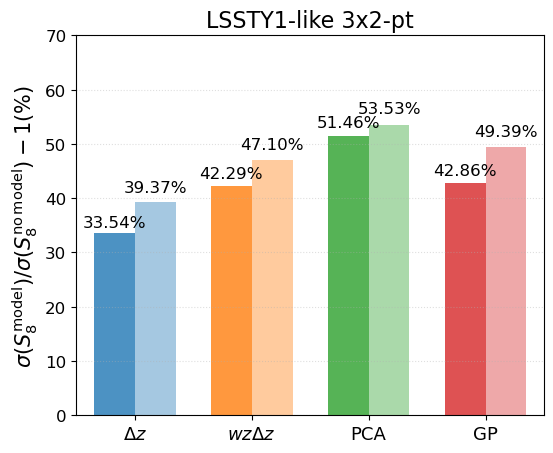

In [85]:
# Prepare data
methods = [r'$\Delta z$', r'$wz\Delta z$', 'PCA', 'GP']
colors = ['C0', 'C1', 'C2', 'C3']

def compute_sigma(chain, param='σ8'):
    p = chain[param] * np.sqrt(chain["Ωm"] / 0.3)
    return np.std(p)

# Compute std deviations for each method (numerical + analytical)
p_fixed_s_num = compute_sigma(chain_Y1_3x2_nomarg)
p_fixed_s_ana = np.nan  # no analytical version for fixed model

p_dz_s_num    = compute_sigma(chain_Y1_3x2_dz_num)
p_dz_s_ana    = compute_sigma(chain_Y1_3x2_dz_ana)

p_wzdz_s_num  = compute_sigma(chain_Y1_3x2_wzdz_num)
p_wzdz_s_ana  = compute_sigma(chain_Y1_3x2_wzdz_ana)

p_pca_s_num   = compute_sigma(chain_Y1_3x2_PCA_num)
p_pca_s_ana   = compute_sigma(chain_Y1_3x2_PCA_ana)

p_gp_s_num    = compute_sigma(chain_Y1_3x2_gp_num)
p_gp_s_ana    = compute_sigma(chain_Y1_3x2_gp_ana)

sigmas_num = 100*(np.array([p_dz_s_num, p_wzdz_s_num, p_pca_s_num, p_gp_s_num])/p_fixed_s_num - 1)
sigmas_ana = 100*(np.array([p_dz_s_ana, p_wzdz_s_ana, p_pca_s_ana, p_gp_s_ana])/p_fixed_s_num - 1)   

# --------------------------------------------
# Plot setup: two bars per method (num vs ana)
# --------------------------------------------
fig, ax = plt.subplots(figsize=(6, 5))

xpos = np.arange(len(methods))
bar_width = 0.35

# Plot numerical (solid) and analytical (transparent)
bars_num = ax.bar(xpos - bar_width/2, sigmas_num, width=bar_width,
                  color=colors, alpha=0.8,)
bars_ana = ax.bar(xpos + bar_width/2, sigmas_ana, width=bar_width,
                  color=colors, alpha=0.4)

# Aesthetics
ax.set_xticks(xpos)
ax.set_xticklabels(methods, fontsize=13)
ax.set_ylabel(r'$\sigma(S_8^{\rm model})/\sigma(S_8^{\rm no \, model}) - 1 (\%)$', fontsize=15)
ax.tick_params(axis='y', labelsize=12)
ax.grid(axis='y', linestyle=':', alpha=0.4)
ax.set_xlim(-0.5, len(methods)-0.5)
ax.set_ylim(0, 70)    

# Annotate values above bars
for x, s in zip(xpos, sigmas_num):
    if not np.isnan(s):
        ax.text(x - bar_width/2, s * 1.02, f"{s:.2f}%", ha='center', va='bottom', fontsize=12)
for x, s in zip(xpos, sigmas_ana):
    if not np.isnan(s):
        ax.text(x + bar_width/2, s * 1.03, f"{s:.2f}%", ha='center', va='bottom', fontsize=12)

# Legend & title
ax.legend(fontsize=11, frameon=False)
plt.title("LSSTY1-like 3x2-pt", fontsize=16)
plt.tight_layout()
plt.savefig("./paper_plots/Y1_S8_comp.pdf", bbox_inches='tight', pad_inches=0)

/tmp/ipykernel_18760/2691811653.py:60: UserWarning: No artists with labels found to put in legend.  Note that artists whose label start with an underscore are ignored when legend() is called with no argument.
  ax.legend(fontsize=11, frameon=False)


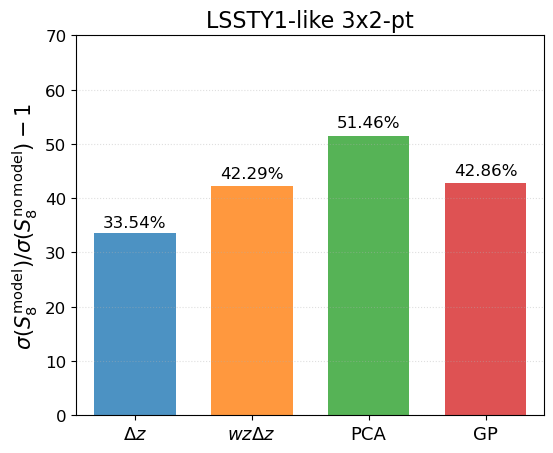

In [55]:
# Prepare data
methods = [r'$\Delta z$', r'$wz\Delta z$', 'PCA', 'GP']
colors = ['C0', 'C1', 'C2', 'C3']

def compute_sigma(chain, param='σ8'):
    p = chain[param] * np.sqrt(chain["Ωm"] / 0.3)
    return np.std(p)

# Compute std deviations for each method (numerical + analytical)
p_fixed_s_num = compute_sigma(chain_Y1_3x2_nomarg)
p_fixed_s_ana = np.nan  # no analytical version for fixed model

p_dz_s_num    = compute_sigma(chain_Y1_3x2_dz_num)
p_dz_s_ana    = compute_sigma(chain_Y1_3x2_dz_ana)

p_wzdz_s_num  = compute_sigma(chain_Y1_3x2_wzdz_num)
p_wzdz_s_ana  = compute_sigma(chain_Y1_3x2_wzdz_ana)

p_pca_s_num   = compute_sigma(chain_Y1_3x2_PCA_num)
p_pca_s_ana   = compute_sigma(chain_Y1_3x2_PCA_ana)

p_gp_s_num    = compute_sigma(chain_Y1_3x2_gp_num)
p_gp_s_ana    = compute_sigma(chain_Y1_3x2_gp_ana)

sigmas_num = 100*(np.array([p_dz_s_num, p_wzdz_s_num, p_pca_s_num, p_gp_s_num])/p_fixed_s_num - 1)
sigmas_ana = 100*(np.array([p_dz_s_ana, p_wzdz_s_ana, p_pca_s_ana, p_gp_s_ana])/p_fixed_s_num - 1)   

# --------------------------------------------
# Plot setup: two bars per method (num vs ana)
# --------------------------------------------
fig, ax = plt.subplots(figsize=(6, 5))

xpos = np.arange(len(methods))
bar_width = 0.35

# Plot numerical (solid) and analytical (transparent)
bars_num = ax.bar(xpos, sigmas_num, width=2*bar_width,
                  color=colors, alpha=0.8,)
#bars_ana = ax.bar(xpos + bar_width/2, sigmas_ana, width=bar_width,
#                  color=colors, alpha=0.4)

# Aesthetics
ax.set_xticks(xpos)
ax.set_xticklabels(methods, fontsize=13)
ax.set_ylabel(r'$\sigma(S_8^{\rm model})/\sigma(S_8^{\rm no \, model}) - 1$', fontsize=15)
ax.tick_params(axis='y', labelsize=12)
ax.grid(axis='y', linestyle=':', alpha=0.4)
ax.set_xlim(-0.5, len(methods)-0.5)
ax.set_ylim(0, 70)    

# Annotate values above bars
for x, s in zip(xpos, sigmas_num):
    if not np.isnan(s):
        ax.text(x, s * 1.02, f"{s:.2f}%", ha='center', va='bottom', fontsize=12)
#for x, s in zip(xpos, sigmas_ana):
#    if not np.isnan(s):
#        ax.text(x + bar_width/2, s * 1.03, f"{s:.2f}%", ha='center', va='bottom', fontsize=12)

# Legend & title
ax.legend(fontsize=11, frameon=False)
plt.title("LSSTY1-like 3x2-pt", fontsize=16)
plt.tight_layout()
plt.savefig("./paper_plots/Y1_S8_comp_simple.pdf", bbox_inches='tight', pad_inches=0)

In [56]:
(0.00181-0.00172)/0.00181

0.04972375690607736

In [57]:
print((0.00163-0.0012)/0.0012)
print((0.00172-0.0012)/0.0012)
print((0.00181-0.0012)/0.0012)
print((0.00175-0.0012)/0.0012)

0.3583333333333334
0.4333333333333334
0.5083333333333334
0.4583333333333335


In [58]:
print((0.00172-0.00163)/0.00163)
print((0.00181-0.00163)/0.00163)
print((0.00175-0.00163)/0.00163)

0.05521472392638038
0.11042944785276076
0.07361963190184055


## Likelihood

In [59]:
cls_3x2_nomarg   = np.transpose(np.transpose(np.array(chain_Y1_3x2_nomarg))[14:622])
xi2_3x2_nomarg  = np.array(chain_Y1_3x2_nomarg['lp'])
data_3x2_nomarg  = np.load("sompz_fake_chains/nomarg/Y1_3x2_nomarg_TAP_0.65_init_ϵ_0.005/data_1.npz")

In [60]:
lkl_3x2_nomarg.shape

NameError: name 'lkl_3x2_nomarg' is not defined

In [ ]:
lkl_3x2_nomarg_m, lkl_3x2_nomarg_s   = np.mean(lkl_3x2_nomarg, axis=1), np.std(lkl_3x2_nomarg, axis=1)

: 

: 

In [ ]:
lkl_3x2_nomarg_cles  = [pacc.ClTheoryEnsemble(cle_3x2,  np.array(lkl_3x2_nomarg[i]))  for i in range(len(lkl_3x2_nomarg))]

: 

: 

In [ ]:
sel_3x2  = np.random.choice(len(lkl_3x2_nomarg), 50)

: 

: 

In [ ]:
cross_pairs =  [['source_0', 'lens_0'],
 ['source_0', 'lens_1'],
 ['source_0', 'lens_2'],
 ['source_0', 'lens_3'],
 ['source_0', 'lens_4'],
 ['source_1', 'lens_0'],
 ['source_1', 'lens_1'],
 ['source_1', 'lens_2'],
 ['source_1', 'lens_3'],
 ['source_1', 'lens_4'],
 ['source_2', 'lens_0'],
 ['source_2', 'lens_1'],
 ['source_2', 'lens_2'],
 ['source_2', 'lens_3'],
 ['source_2', 'lens_4'],
 ['source_3', 'lens_0'],
 ['source_3', 'lens_1'],
 ['source_3', 'lens_2'],
 ['source_3', 'lens_3'],
 ['source_3', 'lens_4'],
 ['source_4', 'lens_0'],
 ['source_4', 'lens_1'],
 ['source_4', 'lens_2'],
 ['source_4', 'lens_3'],
 ['source_4', 'lens_4']]

: 

: 

In [ ]:
g = pacc.plot_cls([[cle_3x2], lkl_3x2_nomarg_cles[sel_3x2]], cle_3x2.pairs,
                configs=[
                    {"colors":['black'], "show_legend":False},
                    {"alpha":0.8, "Xi2s":-xi2_3x2_nomarg[sel_3x2],
                    "show_legend":False, "show_colobar":True}])
g.savefig("./paper_plots/validation_3x2.pdf", bbox_inches='tight')

: 

: 

: 

: 